# Team pressure analysis
Barca (team 0) vs Atletico (team 1) — Barca-Atletico first half

Covers: proximity pressure, passing-lane pressure, combined team pressure events, pressure by pitch zone, defensive line height, and time-to-press after losing the ball.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import paths

FPS = 25
PITCH_LENGTH = 105
PITCH_WIDTH = 68

player_frame_table = pd.read_parquet(paths.PLAYER_FRAME_TABLE_CACHE_PATH)
ball_frame_table = pd.read_parquet(paths.BALL_FRAME_TABLE_CACHE_PATH)

## 0. Team defensive baseline
Average depth of each team's back line (last-3 defenders), computed once up front, restricted to frames where that team is out of possession (their actual defending shape, not inflated by attacking-phase positioning). Used in section 1 to tell "stepped out to press" apart from "block was already sitting there".

In [2]:
LINE_HEIGHT_DEFENDERS_N = 3

_poss_for_baseline = ball_frame_table[["frame_idx", "possession_team"]]

_outfield_baseline = player_frame_table[player_frame_table["role"] == "player"].dropna(subset=["pitch_x", "pitch_y"]).copy()
_outfield_baseline = _outfield_baseline.merge(_poss_for_baseline, on="frame_idx", how="left")
_outfield_baseline = _outfield_baseline[
    _outfield_baseline["possession_team"].notna() &
    (_outfield_baseline["team"] != _outfield_baseline["possession_team"])
]  # keep only frames where this team is out of possession -- their real defensive shape

_outfield_baseline["dist_from_own_goal"] = np.where(
    _outfield_baseline["team"] == 0,
    _outfield_baseline["pitch_x"],
    PITCH_LENGTH - _outfield_baseline["pitch_x"]
)
_outfield_baseline["dist_from_own_goal"] = _outfield_baseline["dist_from_own_goal"].clip(0, PITCH_LENGTH)

team_defensive_line_avg = (
    _outfield_baseline.sort_values("dist_from_own_goal")
    .groupby(["frame_idx", "team"])
    .head(LINE_HEIGHT_DEFENDERS_N)
    .groupby("team")["dist_from_own_goal"]
    .mean()
    .to_dict()
)
print("team average defensive line depth, out-of-possession only (last-3 defenders, m from own goal):", team_defensive_line_avg)

team average defensive line depth, out-of-possession only (last-3 defenders, m from own goal): {0: 44.869230917514955, 1: 27.800214093805053}


## 0b. Stoppage detection
A no-carrier gap in `carrier_track_id` lasting >= `STOPPAGE_GAP_SEC` (10s) is flagged as a real stoppage (injury, goal, VAR check, cooling break) rather than ordinary loose-ball noise -- verified by eye against the video. `stoppage_frame_lookup` is a per-frame boolean used downstream (sections 4, 12, 14) so dead time doesn't get silently counted as live out-of-possession play.

In [3]:
STOPPAGE_GAP_SEC = 10.0
STOPPAGE_GAP_FRAMES = int(STOPPAGE_GAP_SEC * FPS)

carrier_missing = ball_frame_table[["frame_idx", "carrier_track_id"]].sort_values("frame_idx").reset_index(drop=True)
carrier_missing["is_missing"] = carrier_missing["carrier_track_id"].isna()
carrier_missing["gap_id"] = (carrier_missing["is_missing"] != carrier_missing["is_missing"].shift()).cumsum()

gap_runs = (
    carrier_missing[carrier_missing["is_missing"]]
    .groupby("gap_id")
    .agg(start_frame=("frame_idx", "first"), end_frame=("frame_idx", "last"), n_frames=("frame_idx", "count"))
    .reset_index(drop=True)
)
gap_runs["duration_sec"] = gap_runs["n_frames"] / FPS

stoppages = gap_runs[gap_runs["duration_sec"] >= STOPPAGE_GAP_SEC].reset_index(drop=True)

# vectorized frame -> is_stoppage lookup
_stoppage_starts = stoppages["start_frame"].values
_stoppage_ends = stoppages["end_frame"].values

all_frames = ball_frame_table[["frame_idx"]].drop_duplicates().sort_values("frame_idx").reset_index(drop=True)
_frame_vals = all_frames["frame_idx"].values
_idx = np.searchsorted(_stoppage_starts, _frame_vals, side="right") - 1
_valid = _idx >= 0
_in_range = np.zeros(len(_frame_vals), dtype=bool)
_idx_valid = _idx[_valid]
_in_range[_valid] = _frame_vals[_valid] <= _stoppage_ends[_idx_valid]
all_frames["is_stoppage"] = _in_range

stoppage_frame_lookup = all_frames.set_index("frame_idx")["is_stoppage"]

print(f"{len(stoppages)} stoppages >= {STOPPAGE_GAP_SEC}s flagged, covering {stoppages['n_frames'].sum()} frames "
      f"({stoppages['duration_sec'].sum():.1f}s total dead time)")

26 stoppages >= 10.0s flagged, covering 11267 frames (450.7s total dead time)


## 1. Proximity pressure — distance from each off-ball defender to the ball carrier
A defender only counts as "pressuring" if they're close AND (a) they're closing the distance fast (actively running at the carrier, >=2.5 m/s), or (b) they're within touch-tight range (<1.5m) regardless of speed, or (c) they're clearly ahead of their team's own out-of-possession baseline line (stepped out of the block). This is meant to separate real pressing from a deep, compact block that's simply already sitting near the ball because the attacker walked into it. Thresholds tightened from the first pass -- 1.0 m/s and 2.0m were too permissive and let most of a passive block still count as "pressuring".

In [4]:
PRESSURE_DIST_THRESH_M = 5.0
CLOSING_WINDOW_FRAMES = 12       # ~0.5s @ 25fps, window used to measure closing speed
CLOSING_SPEED_THRESH_MPS = 2.5   # must be closing at least this fast to count as an active press from open play (walking pace was too permissive)
TIGHT_MARK_DIST_M = 1.5          # inside this range, counts as pressure even without active closing (touch-tight)
STEP_OUT_MARGIN_M = 4.0          # must be at least this far ahead of the team's own average line depth

carrier_pos = ball_frame_table[
    ["frame_idx", "carrier_track_id", "carrier_team", "possession_team", "ball_pitch_x", "ball_pitch_y"]
]

pft = player_frame_table.merge(carrier_pos, on="frame_idx", how="left")

off_ball = pft[
    (pft["role"] == "player") &
    pft["carrier_track_id"].notna() &
    (pft["track_id"] != pft["carrier_track_id"]) &
    (pft["team"] != pft["carrier_team"])
].copy()

off_ball["dist_to_carrier"] = (
    (off_ball["pitch_x"] - off_ball["ball_pitch_x"]) ** 2 +
    (off_ball["pitch_y"] - off_ball["ball_pitch_y"]) ** 2
) ** 0.5

off_ball_pressure = off_ball.dropna(subset=["dist_to_carrier"]).copy()
off_ball_pressure = off_ball_pressure.sort_values(["track_id", "frame_idx"]).reset_index(drop=True)

# closing speed: how fast dist_to_carrier has been shrinking over the last CLOSING_WINDOW_FRAMES for this player
off_ball_pressure["dist_to_carrier_prev"] = off_ball_pressure.groupby("track_id")["dist_to_carrier"].shift(CLOSING_WINDOW_FRAMES)
off_ball_pressure["frame_gap"] = off_ball_pressure["frame_idx"] - off_ball_pressure.groupby("track_id")["frame_idx"].shift(CLOSING_WINDOW_FRAMES)
off_ball_pressure["closing_speed_mps"] = np.where(
    (off_ball_pressure["frame_gap"] > 0) & (off_ball_pressure["frame_gap"] <= CLOSING_WINDOW_FRAMES * 2),
    (off_ball_pressure["dist_to_carrier_prev"] - off_ball_pressure["dist_to_carrier"]) / (off_ball_pressure["frame_gap"] / FPS),
    np.nan
)

# stepped ahead of the team's own habitual defensive line -> not just standing in the block
off_ball_pressure["dist_from_own_goal"] = np.where(
    off_ball_pressure["team"] == 0,
    off_ball_pressure["pitch_x"],
    PITCH_LENGTH - off_ball_pressure["pitch_x"]
)
off_ball_pressure["dist_from_own_goal"] = off_ball_pressure["dist_from_own_goal"].clip(0, PITCH_LENGTH)
off_ball_pressure["team_line_avg"] = off_ball_pressure["team"].map(team_defensive_line_avg)
off_ball_pressure["stepped_out_of_line"] = (
    off_ball_pressure["dist_from_own_goal"] >= off_ball_pressure["team_line_avg"] + STEP_OUT_MARGIN_M
)

off_ball_pressure["is_pressuring"] = (
    (off_ball_pressure["dist_to_carrier"] < PRESSURE_DIST_THRESH_M) &
    (
        (off_ball_pressure["dist_to_carrier"] < TIGHT_MARK_DIST_M) |
        (off_ball_pressure["closing_speed_mps"].fillna(0) >= CLOSING_SPEED_THRESH_MPS) |
        off_ball_pressure["stepped_out_of_line"]
    )
)

team_pressure_per_frame = (
    off_ball_pressure.groupby(["frame_idx", "team", "carrier_team", "possession_team"], as_index=False)
    .agg(
        n_pressing=("is_pressuring", "sum"),
        n_defenders_on_pitch=("track_id", "nunique"),
        min_dist_to_carrier=("dist_to_carrier", "min"),
    )
)
team_pressure_per_frame["pressing_intensity"] = (
    team_pressure_per_frame["n_pressing"] / team_pressure_per_frame["n_defenders_on_pitch"]
)

## 2. Passing-lane pressure — how covered are the carrier's passing options

In [5]:
MIN_LANE_LENGTH_M = 3.0
TIGHT_LANE_THRESH_M = 1.5
CONTESTED_LANE_THRESH_M = 3.0

carrier_frames = pft[(pft["role"] == "player") & pft["carrier_track_id"].notna()].copy()

teammates = carrier_frames[
    (carrier_frames["team"] == carrier_frames["carrier_team"]) &
    (carrier_frames["track_id"] != carrier_frames["carrier_track_id"])
]
opponents = carrier_frames[carrier_frames["team"] != carrier_frames["carrier_team"]]

carrier_player_pos = (
    player_frame_table[player_frame_table["is_carrier"] == True]
    [["frame_idx", "track_id", "pitch_x", "pitch_y"]]
    .rename(columns={"track_id": "carrier_track_id", "pitch_x": "carrier_x", "pitch_y": "carrier_y"})
    .drop_duplicates(subset="frame_idx", keep="first")
)

teammate_pos = teammates[["frame_idx", "track_id", "pitch_x", "pitch_y"]].rename(
    columns={"track_id": "teammate_id", "pitch_x": "tm_x", "pitch_y": "tm_y"}
)
opponent_pos = opponents[["frame_idx", "track_id", "pitch_x", "pitch_y"]].rename(
    columns={"track_id": "opponent_id", "pitch_x": "opp_x", "pitch_y": "opp_y"}
)

lanes = teammate_pos.merge(opponent_pos, on="frame_idx", how="inner")
lanes = lanes.merge(carrier_player_pos, on="frame_idx", how="inner")
lanes = lanes.dropna(subset=["carrier_x", "carrier_y"])

Ax, Ay = lanes["carrier_x"].values, lanes["carrier_y"].values
Bx, By = lanes["tm_x"].values, lanes["tm_y"].values
Px, Py = lanes["opp_x"].values, lanes["opp_y"].values

ABx, ABy = Bx - Ax, By - Ay
APx, APy = Px - Ax, Py - Ay

seg_len_sq = ABx ** 2 + ABy ** 2
seg_len_sq = np.where(seg_len_sq == 0, 1e-9, seg_len_sq)

t = (APx * ABx + APy * ABy) / seg_len_sq
t_clipped = np.clip(t, 0.0, 1.0)

closest_x = Ax + t_clipped * ABx
closest_y = Ay + t_clipped * ABy
perp_dist = np.sqrt((Px - closest_x) ** 2 + (Py - closest_y) ** 2)

lanes["t"] = t
lanes["lane_perp_dist"] = perp_dist
lanes["lane_length_m"] = np.sqrt(seg_len_sq)

valid_lanes = lanes[
    (lanes["lane_length_m"] >= MIN_LANE_LENGTH_M) &
    (lanes["t"] >= 0.15) &
    (lanes["t"] <= 0.85)
].copy()

valid_lanes["lane_tight_block"] = valid_lanes["lane_perp_dist"] < TIGHT_LANE_THRESH_M
valid_lanes["lane_contested"] = valid_lanes["lane_perp_dist"] < CONTESTED_LANE_THRESH_M

lane_status = (
    valid_lanes.groupby(["frame_idx", "teammate_id"], as_index=False)
    .agg(lane_tight_block=("lane_tight_block", "any"), lane_contested=("lane_contested", "any"))
)

frame_lane_summary = (
    lane_status.groupby("frame_idx", as_index=False)
    .agg(
        n_lanes_total=("teammate_id", "nunique"),
        n_lanes_tight_blocked=("lane_tight_block", "sum"),
        n_lanes_contested=("lane_contested", "sum"),
    )
)
frame_lane_summary["n_lanes_open"] = frame_lane_summary["n_lanes_total"] - frame_lane_summary["n_lanes_contested"]
frame_lane_summary["frac_tight_blocked"] = frame_lane_summary["n_lanes_tight_blocked"] / frame_lane_summary["n_lanes_total"]
frame_lane_summary["frac_contested"] = frame_lane_summary["n_lanes_contested"] / frame_lane_summary["n_lanes_total"]

frame_lane_summary = frame_lane_summary.merge(
    carrier_pos[["frame_idx", "carrier_team", "possession_team"]], on="frame_idx", how="left"
)


## 3. Unified team pressure signal + events
Combines proximity pressure OR lane-blocking pressure, then excludes own-penalty-box frames (16.5m from own goal) since compact box defending is a different phenomenon from active pressing. This corrected `under_team_pressure` definition is used everywhere downstream (events, zone breakdown, time-to-press, pass resistance, weighted intensity).
Note: `n_pressing`/`pressing_intensity` now come from the closing-speed + step-out-of-line gated definition in section 1, not raw distance -- so a passive deep block no longer inflates this on its own. The lane-blocking signal (section 2) is left distance-based for now, since being within `TIGHT_LANE_THRESH_M` of an actual pass lane is a real obstruction regardless of how the defender got there.

In [6]:
N_PRESSING_THRESH = 2
FRAC_TIGHT_BLOCKED_THRESH = 0.375
MIN_EVENT_DURATION_SEC = 0.5
GAP_TOLERANCE_FRAMES = 5
BOX_DEPTH_M = 16.5

team_pressure_full = team_pressure_per_frame.merge(
    frame_lane_summary[["frame_idx", "n_lanes_total", "n_lanes_tight_blocked",
                         "n_lanes_contested", "frac_tight_blocked", "frac_contested"]],
    on="frame_idx",
    how="left"
)

ball_pos_by_frame = ball_frame_table[["frame_idx", "ball_pitch_x", "ball_pitch_y"]].rename(
    columns={"ball_pitch_x": "press_x", "ball_pitch_y": "press_y"}
)
team_pressure_full = team_pressure_full.merge(ball_pos_by_frame, on="frame_idx", how="left")

tpf = team_pressure_full.copy()
tpf["frac_tight_blocked"] = tpf["frac_tight_blocked"].fillna(0)

tpf["in_own_box"] = np.where(
    tpf["team"] == 0,
    tpf["press_x"] <= BOX_DEPTH_M,
    tpf["press_x"] >= PITCH_LENGTH - BOX_DEPTH_M
)

tpf["under_team_pressure"] = (
    ((tpf["n_pressing"] >= N_PRESSING_THRESH) | (tpf["frac_tight_blocked"] >= FRAC_TIGHT_BLOCKED_THRESH)) &
    (~tpf["in_own_box"])
)

# carry the corrected flag back onto team_pressure_full so every downstream section uses the same definition
team_pressure_full["under_team_pressure"] = tpf["under_team_pressure"]

tpf = tpf.sort_values(["team", "frame_idx"]).reset_index(drop=True)

events_list = []
for team_id, grp in tpf.groupby("team"):
    grp = grp.sort_values("frame_idx").reset_index(drop=True)

    is_press = grp["under_team_pressure"].values.copy()
    frames = grp["frame_idx"].values
    i, n = 0, len(is_press)
    while i < n:
        if not is_press[i]:
            j = i
            while j < n and not is_press[j]:
                j += 1
            gap_frame_span = frames[j - 1] - frames[i] + 1 if j > i else 0
            if i > 0 and j < n and gap_frame_span <= GAP_TOLERANCE_FRAMES:
                is_press[i:j] = True
            i = j
        else:
            i += 1
    grp["under_team_pressure_bridged"] = is_press

    grp["state_change"] = (grp["under_team_pressure_bridged"] != grp["under_team_pressure_bridged"].shift()).cumsum()
    runs = (
        grp.groupby("state_change")
        .agg(
            start_frame=("frame_idx", "first"),
            end_frame=("frame_idx", "last"),
            n_frames=("frame_idx", "count"),
            under_pressure=("under_team_pressure_bridged", "first"),
            possession_team=("possession_team", "first"),
            mean_n_pressing=("n_pressing", "mean"),
            mean_frac_tight_blocked=("frac_tight_blocked", "mean"),
        )
        .reset_index(drop=True)
    )
    runs["team"] = team_id
    events_list.append(runs)

team_pressure_events = pd.concat(events_list, ignore_index=True)
team_pressure_events = team_pressure_events[team_pressure_events["under_pressure"]].copy()
team_pressure_events["duration_sec"] = team_pressure_events["n_frames"] / FPS
team_pressure_events = team_pressure_events[
    team_pressure_events["duration_sec"] >= MIN_EVENT_DURATION_SEC
].reset_index(drop=True)

print("total team pressure events:", len(team_pressure_events))
print(team_pressure_events.groupby("team")["duration_sec"].describe())


total team pressure events: 249
      count      mean       std   min   25%   50%   75%   max
team                                                         
0     105.0  1.612952  1.532163  0.52  0.68  1.08  1.88  9.12
1     144.0  1.362778  0.898766  0.52  0.76  1.12  1.60  5.60


## 4. Total pressure time, normalized by each team's out-of-possession window

In [7]:
total_pressure_frames_by_team = team_pressure_events.groupby("team")["n_frames"].sum()
total_pressure_seconds_by_team = total_pressure_frames_by_team / FPS

bft_live = ball_frame_table.merge(stoppage_frame_lookup.rename("is_stoppage"), left_on="frame_idx", right_index=True, how="left")
bft_live["is_stoppage"] = bft_live["is_stoppage"].fillna(False)
bft_live = bft_live[~bft_live["is_stoppage"]]  # dead time isn't real out-of-possession play, exclude it

possession_frames_by_team = bft_live["possession_team"].value_counts(dropna=True)
total_labeled_frames = bft_live["possession_team"].notna().sum()
out_of_possession_frames = {
    0: total_labeled_frames - possession_frames_by_team.get(0, 0),
    1: total_labeled_frames - possession_frames_by_team.get(1, 0),
}
out_of_possession_seconds = {k: v / FPS for k, v in out_of_possession_frames.items()}

match_duration_sec = (player_frame_table["frame_idx"].max() + 1) / FPS

print("total pressure seconds by team:\n", total_pressure_seconds_by_team)
print(f"\nmatch duration: {match_duration_sec:.1f}s ({stoppages['duration_sec'].sum():.1f}s of that is stoppage time, excluded below)")
for team_id in [0, 1]:
    pct = total_pressure_seconds_by_team.get(team_id, 0) / out_of_possession_seconds[team_id] * 100
    print(f"team {team_id}: {total_pressure_seconds_by_team.get(team_id, 0):.1f}s pressing / "
          f"{out_of_possession_seconds[team_id]:.1f}s out of possession = {pct:.1f}% pressing intensity")

total pressure seconds by team:
 team
0    169.36
1    196.24
Name: n_frames, dtype: float64

match duration: 2813.0s (450.7s of that is stoppage time, excluded below)
team 0: 169.4s pressing / 602.9s out of possession = 28.1% pressing intensity
team 1: 196.2s pressing / 895.7s out of possession = 21.9% pressing intensity


## 5. Pressure by pitch zone (own / middle / attacking third, relative to pressing team's attack direction)
Uses the corrected `under_team_pressure` from section 3 (already excludes own-box frames).

In [8]:
tpf_zone = team_pressure_full.copy()

def classify_zone(row):
    x = row["press_x"]
    if pd.isna(x):
        return None
    if row["team"] == 0:
        if x < 35: return "own_third"
        elif x < 70: return "middle_third"
        else: return "attacking_third"
    else:
        if x > 70: return "own_third"
        elif x > 35: return "middle_third"
        else: return "attacking_third"

tpf_zone["press_zone"] = tpf_zone.apply(classify_zone, axis=1)

pressing_only = tpf_zone[tpf_zone["under_team_pressure"] & tpf_zone["press_zone"].notna()]

zone_counts = pressing_only.groupby(["team", "press_zone"]).size().unstack(fill_value=0)
zone_pct = zone_counts.div(zone_counts.sum(axis=1), axis=0) * 100

print("pressure frames by team and zone:\n", zone_counts)
print("\n% distribution within each team's own pressing:\n", zone_pct)


pressure frames by team and zone:
 press_zone  attacking_third  middle_third  own_third
team                                                
0                      2029          1559        736
1                       530          2814       1978

% distribution within each team's own pressing:
 press_zone  attacking_third  middle_third  own_third
team                                                
0                 46.924144     36.054579  17.021277
1                  9.958662     52.874859  37.166479


## 6. Defensive line height (distance from own goal, last-1 and last-3 defenders)

In [9]:
BOUNDS_TOLERANCE_M = 2.0

outfield = player_frame_table[player_frame_table["role"] == "player"].copy()
outfield = outfield.dropna(subset=["pitch_x", "pitch_y"])

in_bounds = (
    (outfield["pitch_x"] >= -BOUNDS_TOLERANCE_M) & (outfield["pitch_x"] <= PITCH_LENGTH + BOUNDS_TOLERANCE_M) &
    (outfield["pitch_y"] >= -BOUNDS_TOLERANCE_M) & (outfield["pitch_y"] <= PITCH_WIDTH + BOUNDS_TOLERANCE_M)
)
outfield = outfield[in_bounds].copy()

outfield["dist_from_own_goal"] = np.where(
    outfield["team"] == 0,
    outfield["pitch_x"],
    PITCH_LENGTH - outfield["pitch_x"]
)
outfield["dist_from_own_goal"] = outfield["dist_from_own_goal"].clip(0, PITCH_LENGTH)

def compute_line_height(df, n_defenders):
    return (
        df.sort_values("dist_from_own_goal")
        .groupby(["frame_idx", "team"])
        .head(n_defenders)
        .groupby(["frame_idx", "team"], as_index=False)["dist_from_own_goal"]
        .mean()
        .rename(columns={"dist_from_own_goal": "line_height_m"})
    )

def remove_outliers_iqr(df, col, group_cols):
    parts = []
    for _, g in df.groupby(group_cols):
        q1, q3 = g[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        parts.append(g[(g[col] >= lo) & (g[col] <= hi)])
    return pd.concat(parts, ignore_index=True)

poss = ball_frame_table[["frame_idx", "possession_team"]]

line_last1 = compute_line_height(outfield, 1).merge(poss, on="frame_idx", how="left")
line_last3 = compute_line_height(outfield, 3).merge(poss, on="frame_idx", how="left")

line_last1_clean = remove_outliers_iqr(line_last1, "line_height_m", ["team"])
line_last3_clean = remove_outliers_iqr(line_last3, "line_height_m", ["team"])

avg_line_height = line_last3_clean.groupby("team")["line_height_m"].mean()

print("last-1 defender:\n", line_last1_clean.groupby("team")["line_height_m"].agg(["mean", "median", "std"]))
print("\nlast-3 defenders avg:\n", line_last3_clean.groupby("team")["line_height_m"].agg(["mean", "median", "std"]))


last-1 defender:
            mean     median        std
team                                 
0     44.577749  49.330734  19.090735
1     26.230183  22.755009  17.660295

last-3 defenders avg:
            mean     median        std
team                                 
0     47.792956  51.421569  19.834561
1     28.633750  24.759707  18.139512


## 7. Defensive line height — pitch visualization

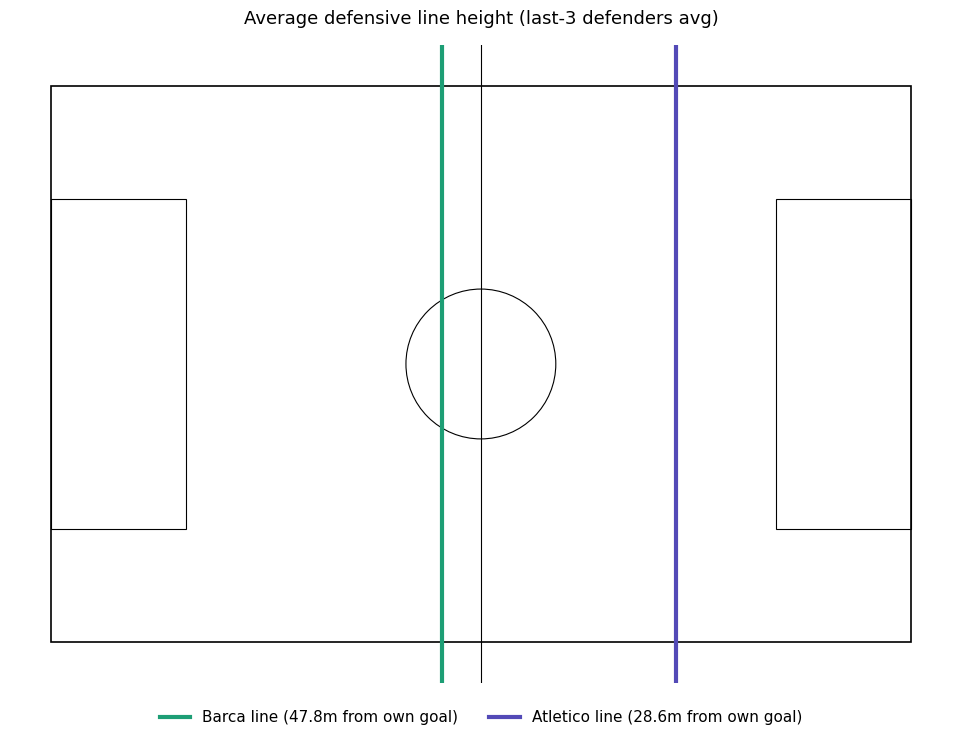

In [10]:
team0_line_x = avg_line_height[0]
team1_line_x = PITCH_LENGTH - avg_line_height[1]

fig, ax = plt.subplots(figsize=(12, 7.5))

ax.add_patch(patches.Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH, fill=False, color="black", linewidth=1.2))
ax.axvline(PITCH_LENGTH / 2, color="black", linewidth=0.8)
ax.add_patch(patches.Circle((PITCH_LENGTH / 2, PITCH_WIDTH / 2), 9.15, fill=False, color="black", linewidth=0.8))

box_depth, box_width = 16.5, 40.3
ax.add_patch(patches.Rectangle((0, (PITCH_WIDTH - box_width) / 2), box_depth, box_width, fill=False, color="black", linewidth=0.8))
ax.add_patch(patches.Rectangle((PITCH_LENGTH - box_depth, (PITCH_WIDTH - box_width) / 2), box_depth, box_width, fill=False, color="black", linewidth=0.8))

ax.axvline(team0_line_x, color="#1D9E75", linewidth=3, label=f"Barca line ({team0_line_x:.1f}m from own goal)")
ax.axvline(team1_line_x, color="#534AB7", linewidth=3, label=f"Atletico line ({avg_line_height[1]:.1f}m from own goal)")

ax.set_xlim(-5, PITCH_LENGTH + 5)
ax.set_ylim(-5, PITCH_WIDTH + 5)
ax.set_aspect("equal")
ax.axis("off")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False, fontsize=11)
ax.set_title("Average defensive line height (last-3 defenders avg)", fontsize=13, pad=15)

plt.tight_layout()
plt.show()


## 8. Time-to-press after losing the ball
Turnovers derived from raw (unsmoothed) carrier-team changes, filtered to stable holds (>=1.5s) to exclude 50/50 scramble noise.

In [11]:
MIN_HOLD_SEC = 1.5
MIN_HOLD_FRAMES = int(MIN_HOLD_SEC * FPS)
MAX_SEARCH_WINDOW_SEC = 10
MAX_SEARCH_WINDOW_FRAMES = MAX_SEARCH_WINDOW_SEC * FPS

raw_carrier = ball_frame_table.dropna(subset=["carrier_team"])[["frame_idx", "carrier_team"]].sort_values("frame_idx").reset_index(drop=True)
raw_carrier["state_change"] = (raw_carrier["carrier_team"] != raw_carrier["carrier_team"].shift()).cumsum()
carrier_runs = (
    raw_carrier.groupby("state_change")
    .agg(start_frame=("frame_idx", "first"), end_frame=("frame_idx", "last"), n_frames=("frame_idx", "count"), carrier_team=("carrier_team", "first"))
    .reset_index(drop=True)
)

stable_runs = carrier_runs[carrier_runs["n_frames"] >= MIN_HOLD_FRAMES].reset_index(drop=True)

turnovers = []
for i in range(len(stable_runs) - 1):
    losing_team = stable_runs.loc[i, "carrier_team"]
    gaining_team = stable_runs.loc[i + 1, "carrier_team"]
    if losing_team != gaining_team:
        turnovers.append({"losing_team": losing_team, "loss_frame": stable_runs.loc[i, "end_frame"]})
turnovers = pd.DataFrame(turnovers)

press_lookup = team_pressure_full[["frame_idx", "team", "under_team_pressure"]].copy()

results = []
for _, row in turnovers.iterrows():
    team_id = row["losing_team"]
    loss_frame = row["loss_frame"]
    window = press_lookup[
        (press_lookup["team"] == team_id) &
        (press_lookup["frame_idx"] >= loss_frame) &
        (press_lookup["frame_idx"] <= loss_frame + MAX_SEARCH_WINDOW_FRAMES) &
        (press_lookup["under_team_pressure"])
    ]
    if len(window) > 0:
        first_press_frame = window["frame_idx"].min()
        results.append({"team": team_id, "loss_frame": loss_frame, "time_to_press_sec": (first_press_frame - loss_frame) / FPS})

time_to_press = pd.DataFrame(results)

print("genuine turnover events:", len(turnovers))
print(f"turnovers with a press detected within {MAX_SEARCH_WINDOW_SEC}s: {len(time_to_press)} / {len(turnovers)}")
print("\ntime-to-press stats by team (seconds):")
print(time_to_press.groupby("team")["time_to_press_sec"].agg(["mean", "median", "min", "max", "count"]))


genuine turnover events: 110
turnovers with a press detected within 10s: 86 / 110

time-to-press stats by team (seconds):
          mean  median   min   max  count
team                                     
0     3.289565    3.36  0.04  9.92     46
1     4.127000    3.60  0.04  9.96     40


## 8b. Counter-press effectiveness -- time-to-press by response speed
Extends section 8: does responding fast to losing the ball actually predict winning it back, or is that just what pressure volume looks like anyway? Turnovers are re-anchored on the opponent's *confirmed* takeover frame (the fix below), not the losing team's own last touch -- anchoring on the losing team's own frame trivially matched `losing_team` in the regain window every time, which is what the corrected version fixes. `time_to_press_sec` (from section 8) is then bucketed into fast (pressed within `COUNTER_PRESS_WINDOW_SEC`) / slow (pressed later, within section 8's `MAX_SEARCH_WINDOW_SEC`) / never.

In [32]:
## Counter-press effectiveness — corrected anchor point
## Bug in prior version: loss_frame is the LAST frame of the losing team's own run, so the window's
## own starting frame trivially matched losing_team every time (100% regain rate for both teams was
## the tell). Fixed by anchoring on the confirmed start of the opponent's next stable run instead.

COUNTER_PRESS_WINDOW_SEC = 5.0
COUNTER_PRESS_WINDOW_FRAMES = int(COUNTER_PRESS_WINDOW_SEC * FPS)

# local carrier lookup -- kept separate from section 14's _carrier_frame_idx/_carrier_team_vals
# (same underlying data, different variable names) so this section runs standalone regardless
# of where it sits relative to section 14
_cp_carrier_lookup = (
    ball_frame_table.dropna(subset=["carrier_team"])[["frame_idx", "carrier_team"]]
    .sort_values("frame_idx")
)
_cp_carrier_frame_idx = _cp_carrier_lookup["frame_idx"].values
_cp_carrier_team_vals = _cp_carrier_lookup["carrier_team"].values

# rebuild turnovers with the opponent's confirmed start frame included
turnovers_fixed = []
for i in range(len(stable_runs) - 1):
    losing_team = stable_runs.loc[i, "carrier_team"]
    gaining_team = stable_runs.loc[i + 1, "carrier_team"]
    if losing_team != gaining_team:
        turnovers_fixed.append({
            "losing_team": losing_team,
            "loss_frame": stable_runs.loc[i, "end_frame"],
            "gain_frame": stable_runs.loc[i + 1, "start_frame"],  # opponent's confirmed takeover, the real turnover boundary
        })
turnovers_fixed = pd.DataFrame(turnovers_fixed)

def regained_after_turnover(losing_team, gain_frame):
    # search strictly AFTER the opponent's takeover frame, not from the losing team's own last touch
    lo = np.searchsorted(_cp_carrier_frame_idx, gain_frame + 1, side="left")
    hi = np.searchsorted(_cp_carrier_frame_idx, gain_frame + COUNTER_PRESS_WINDOW_FRAMES, side="right")
    window_teams = _cp_carrier_team_vals[lo:hi]
    return bool(np.any(window_teams == losing_team))

turnovers_fixed["regained_within_window"] = turnovers_fixed.apply(
    lambda r: regained_after_turnover(r["losing_team"], r["gain_frame"]), axis=1
)

turnovers_annotated = turnovers_fixed.merge(
    time_to_press.rename(columns={"team": "losing_team"}),
    on=["losing_team", "loss_frame"],
    how="left"
)
turnovers_annotated["pressed_fast"] = turnovers_annotated["time_to_press_sec"] <= COUNTER_PRESS_WINDOW_SEC

print("=" * 60)
print("COUNTER-PRESS EFFECTIVENESS")
print("=" * 60)
print(f"{len(turnovers_fixed)} turnovers, checking regain within {COUNTER_PRESS_WINDOW_SEC}s of the opponent's confirmed takeover")

print("\ncounter-press regain rate by team (regained the ball back within window, regardless of press):")
regain_by_team = turnovers_annotated.groupby("losing_team")["regained_within_window"].agg(["mean", "sum", "count"])
regain_by_team["mean"] = (regain_by_team["mean"] * 100).round(1)
print(regain_by_team.rename(columns={"mean": "regain_rate_pct"}))

print(f"\ndoes pressing fast (within {COUNTER_PRESS_WINDOW_SEC}s) actually correlate with winning it back?")
print("regain rate split by whether a press was mounted within the window:")
cross = turnovers_annotated.groupby(["losing_team", "pressed_fast"])["regained_within_window"].agg(["mean", "count"])
cross["mean"] = (cross["mean"] * 100).round(1)
print(cross.rename(columns={"mean": "regain_rate_pct"}))

COUNTER-PRESS EFFECTIVENESS
110 turnovers, checking regain within 5.0s of the opponent's confirmed takeover

counter-press regain rate by team (regained the ball back within window, regardless of press):
             regain_rate_pct  sum  count
losing_team                             
0                       27.3   15     55
1                       20.0   11     55

does pressing fast (within 5.0s) actually correlate with winning it back?
regain rate split by whether a press was mounted within the window:
                          regain_rate_pct  count
losing_team pressed_fast                        
0           False                    10.0     20
            True                     37.1     35
1           False                    22.6     31
            True                     16.7     24


In [34]:
## Counter-press effectiveness — 3-way press-response split (fast / slow / never)
## Replaces the earlier pressed_fast boolean, which folded "pressed slowly" and "never pressed"
## into the same False bucket (NaN <= 5.0 evaluates to False in pandas). These are different claims
## and get separate rows here.

def classify_press_response(t):
    if pd.isna(t):
        return "never"
    elif t <= COUNTER_PRESS_WINDOW_SEC:
        return "fast"
    else:
        return "slow"

turnovers_annotated["press_response"] = turnovers_annotated["time_to_press_sec"].apply(classify_press_response)
turnovers_annotated["press_response"] = pd.Categorical(
    turnovers_annotated["press_response"], categories=["fast", "slow", "never"], ordered=True
)

TEAM_NAMES = {0: "Barca", 1: "Atletico"}

summary = (
    turnovers_annotated.groupby(["losing_team", "press_response"], observed=False)["regained_within_window"]
    .agg(regains="sum", turnovers="count")
    .reset_index()
)
summary["regain_rate_pct"] = (summary["regains"] / summary["turnovers"] * 100).round(1)

print("=" * 70)
print("COUNTER-PRESS EFFECTIVENESS BY PRESS-RESPONSE SPEED")
print("=" * 70)
print(f"fast  = pressed within {COUNTER_PRESS_WINDOW_SEC:.0f}s of the opponent's confirmed takeover")
print(f"slow  = pressed between {COUNTER_PRESS_WINDOW_SEC:.0f}-{MAX_SEARCH_WINDOW_SEC}s (Section 8's search window)")
print(f"never = no press detected within Section 8's {MAX_SEARCH_WINDOW_SEC}s window at all")
print()

for team_id, team_name in TEAM_NAMES.items():
    print(f"{team_name} (team {team_id})")
    print("-" * 40)
    team_rows = (
        summary[summary["losing_team"] == team_id]
        .set_index("press_response")
        .reindex(["fast", "slow", "never"])
    )
    for response, row in team_rows.iterrows():
        n = 0 if pd.isna(row["turnovers"]) else int(row["turnovers"])
        if n == 0:
            print(f"  {response:<6} : n/a (0 turnovers)")
            continue
        regains = int(row["regains"])
        rate = row["regain_rate_pct"]
        print(f"  {response:<6} : {rate:5.1f}% regain rate  ({regains}/{n} turnovers)")
    print()

print("=" * 70)
print("OVERALL (both teams combined)")
print("=" * 70)
overall = (
    turnovers_annotated.groupby("press_response", observed=False)["regained_within_window"]
    .agg(regains="sum", turnovers="count")
    .reindex(["fast", "slow", "never"])
)
overall["regain_rate_pct"] = (overall["regains"] / overall["turnovers"] * 100).round(1)
for response, row in overall.iterrows():
    n = int(row["turnovers"])
    print(f"  {response:<6} : {row['regain_rate_pct']:5.1f}% regain rate  ({int(row['regains'])}/{n} turnovers)")

COUNTER-PRESS EFFECTIVENESS BY PRESS-RESPONSE SPEED
fast  = pressed within 5s of the opponent's confirmed takeover
slow  = pressed between 5-10s (Section 8's search window)
never = no press detected within Section 8's 10s window at all

Barca (team 0)
----------------------------------------
  fast   :  37.1% regain rate  (13/35 turnovers)
  slow   :  18.2% regain rate  (2/11 turnovers)
  never  :   0.0% regain rate  (0/9 turnovers)

Atletico (team 1)
----------------------------------------
  fast   :  16.7% regain rate  (4/24 turnovers)
  slow   :   6.2% regain rate  (1/16 turnovers)
  never  :  40.0% regain rate  (6/15 turnovers)

OVERALL (both teams combined)
  fast   :  28.8% regain rate  (17/59 turnovers)
  slow   :  11.1% regain rate  (3/27 turnovers)
  never  :  25.0% regain rate  (6/24 turnovers)


## 9. Zone-weighted pressing intensity
Attacking-third pressure counts more than own-third pressure (own=1x, middle=2x, attacking=3x), since winning the ball high up the pitch is tactically more valuable. Score is bounded 0-100% by normalizing against the theoretical max (every out-of-possession frame spent pressing in the attacking third).

In [12]:
ZONE_WEIGHTS = {"own_third": 1, "middle_third": 2, "attacking_third": 3}

weighted = tpf_zone[tpf_zone["under_team_pressure"] & tpf_zone["press_zone"].notna()].copy()
weighted["zone_weight"] = weighted["press_zone"].map(ZONE_WEIGHTS)

weighted_pressure_frames = weighted.groupby("team")["zone_weight"].sum()
weighted_pressure_seconds = weighted_pressure_frames / FPS

print("weighted pressure seconds by team (own=1x, middle=2x, attacking=3x):\n", weighted_pressure_seconds)

print("\nzone-weighted pressing intensity, bounded 0-100%:")
for team_id in [0, 1]:
    theoretical_max_seconds = out_of_possession_seconds[team_id] * ZONE_WEIGHTS["attacking_third"]
    pct_of_max = weighted_pressure_seconds.get(team_id, 0) / theoretical_max_seconds * 100
    print(f"team {team_id}: {pct_of_max:.1f}% of theoretical max weighted pressing")


weighted pressure seconds by team (own=1x, middle=2x, attacking=3x):
 team
0    397.64
1    367.84
Name: zone_weight, dtype: float64

zone-weighted pressing intensity, bounded 0-100%:
team 0: 22.0% of theoretical max weighted pressing
team 1: 13.7% of theoretical max weighted pressing


## 10. Passes under pressure — built from scratch (no pass_events cache)
Passes are detected directly from `carrier_track_id` transitions in `ball_frame_table`: a same-team handover is a completed pass, a change of team is an interception. Transitions shorter than `MIN_PASS_DISTANCE_M` are treated as a duel/stray touch and excluded entirely rather than counted as a pass attempt.

Pressure is checked over the `PRESSURE_LOOKBACK_SEC` window leading up to each release frame, using the opposing team's `under_team_pressure` flag from section 3 -- but a pass only counts as "under pressure" if that flag holds for `MIN_SUSTAINED_PRESSURE_FRAMES` *consecutive* frames within the window, not just a single flickering frame. A single-frame OR check let two defenders satisfy the threshold for 1 out of 25 frames and tag the whole pass as pressured, which saturated the signal regardless of how strict the per-defender gate in section 1 was.

In [13]:
PRESSURE_LOOKBACK_SEC = 1.0
PRESSURE_LOOKBACK_FRAMES = int(PRESSURE_LOOKBACK_SEC * FPS)
MIN_SUSTAINED_PRESSURE_FRAMES = 8   # ~0.3s @ 25fps; require a consecutive run, not a single flickering frame

press_flags = press_lookup.set_index(["frame_idx", "team"])["under_team_pressure"]

def was_under_pressure(passer_team, release_frame):
    passer_team = int(passer_team)
    opponent = 1 - passer_team
    release_frame = int(release_frame)
    consecutive = 0
    for f in range(max(0, release_frame - PRESSURE_LOOKBACK_FRAMES), release_frame + 1):
        if press_flags.get((f, opponent), False):
            consecutive += 1
            if consecutive >= MIN_SUSTAINED_PRESSURE_FRAMES:
                return True
        else:
            consecutive = 0
    return False

# --- detect passes + defensive actions from scratch, from carrier_track_id transitions ---
MIN_HOLD_FRAMES_PASS = 2       # ignore single-frame carrier flicker
MIN_PASS_DISTANCE_M = 3.0      # shorter than this -> duel/tackle, not a deliberate pass
MAX_RECEPTION_GAP_FRAMES = 50  # 2s @ FPS; longer gap -> ball likely went out of play, skip

carrier_seq = (
    ball_frame_table.dropna(subset=["carrier_track_id"])
    [["frame_idx", "carrier_track_id", "carrier_team"]]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)
carrier_seq["run_id"] = (carrier_seq["carrier_track_id"] != carrier_seq["carrier_track_id"].shift()).cumsum()

carrier_runs_full = (
    carrier_seq.groupby("run_id")
    .agg(
        track_id=("carrier_track_id", "first"),
        team=("carrier_team", "first"),
        start_frame=("frame_idx", "first"),
        end_frame=("frame_idx", "last"),
        n_frames=("frame_idx", "count"),
    )
    .reset_index(drop=True)
)
carrier_runs_full = carrier_runs_full[carrier_runs_full["n_frames"] >= MIN_HOLD_FRAMES_PASS].reset_index(drop=True)

pos_lookup = player_frame_table.set_index(["frame_idx", "track_id"])[["pitch_x", "pitch_y"]]
role_lookup = player_frame_table.set_index(["frame_idx", "track_id"])["role"]

candidates = []
defensive_actions = []

for i in range(len(carrier_runs_full) - 1):
    passer = carrier_runs_full.loc[i]
    receiver = carrier_runs_full.loc[i + 1]

    gap_frames = receiver["start_frame"] - passer["end_frame"]
    if gap_frames > MAX_RECEPTION_GAP_FRAMES:
        continue  # too long a gap -- ball likely went out of play, not a resolved event

    try:
        passer_pos = pos_lookup.loc[(passer["end_frame"], passer["track_id"])]
        receiver_pos = pos_lookup.loc[(receiver["start_frame"], receiver["track_id"])]
    except KeyError:
        continue

    same_team = receiver["team"] == passer["team"]
    receiver_role = role_lookup.get((receiver["start_frame"], receiver["track_id"]), None)

    if (not same_team) and receiver_role == "goalkeeper":
        continue  # save/claim by the keeper -- not a midfield defensive action, exclude entirely

    dist_m = float(np.hypot(receiver_pos["pitch_x"] - passer_pos["pitch_x"],
                             receiver_pos["pitch_y"] - passer_pos["pitch_y"]))

    if dist_m < MIN_PASS_DISTANCE_M:
        if not same_team:
            defensive_actions.append({
                "defending_team": int(receiver["team"]),
                "attacking_team": int(passer["team"]),
                "action_type": "tackle",
                "frame": int(passer["end_frame"]),
                "x": float(passer_pos["pitch_x"]),
                "y": float(passer_pos["pitch_y"]),
            })
        continue  # same-team short touch = noise; different-team short = captured above as a tackle

    if not same_team:
        defensive_actions.append({
            "defending_team": int(receiver["team"]),
            "attacking_team": int(passer["team"]),
            "action_type": "interception",
            "frame": int(passer["end_frame"]),
            "x": float(passer_pos["pitch_x"]),
            "y": float(passer_pos["pitch_y"]),
        })

    candidates.append({
        "passer_track_id": passer["track_id"],
        "passer_team": int(passer["team"]),
        "receiver_track_id": receiver["track_id"],
        "receiver_team": int(receiver["team"]),
        "release_frame": int(passer["end_frame"]),
        "reception_frame": int(receiver["start_frame"]),
        "release_x": float(passer_pos["pitch_x"]),
        "release_y": float(passer_pos["pitch_y"]),
        "pass_distance_m": dist_m,
        "outcome": "completed" if same_team else "intercepted",
    })

passes_from_scratch = pd.DataFrame(candidates)
defensive_actions = pd.DataFrame(defensive_actions)

print(f"{len(passes_from_scratch)} pass attempts detected (from {len(carrier_runs_full)} carrier runs)")
print(passes_from_scratch["outcome"].value_counts())
print(f"\n{len(defensive_actions)} defensive actions captured (goalkeeper saves/claims excluded)")
print(defensive_actions["action_type"].value_counts())

419 pass attempts detected (from 648 carrier runs)
outcome
completed      334
intercepted     85
Name: count, dtype: int64

110 defensive actions captured (goalkeeper saves/claims excluded)
action_type
interception    85
tackle          25
Name: count, dtype: int64


In [14]:
passes_from_scratch["under_pressure"] = passes_from_scratch.apply(
    lambda row: was_under_pressure(row["passer_team"], row["release_frame"]), axis=1
)
passes_from_scratch["success"] = passes_from_scratch["outcome"] == "completed"

print("passes by team and pressure state:")
print(passes_from_scratch.groupby(["passer_team", "under_pressure"]).size())

pass_summary = (
    passes_from_scratch.groupby(["passer_team", "under_pressure"])["success"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "success_rate"})
)
pass_summary["success_rate"] = (pass_summary["success_rate"] * 100).round(1)
print("\npass success rate by team, under pressure vs not:\n", pass_summary)

print("\ntotal passes attempted while under pressure, by team:")
print(passes_from_scratch[passes_from_scratch["under_pressure"]].groupby("passer_team").size())

passes by team and pressure state:
passer_team  under_pressure
0            False             159
             True               88
1            False              92
             True               80
dtype: int64

pass success rate by team, under pressure vs not:
                             success_rate  count
passer_team under_pressure                     
0           False                   83.6    159
            True                    83.0     88
1           False                   77.2     92
            True                    71.2     80

total passes attempted while under pressure, by team:
passer_team
0    88
1    80
dtype: int64


## 11. Pressure heatmap (spatial density on pitch)
Each team's own-goal orientation preserved (Barca attacks +x, own goal left; Atletico attacks -x, own goal right). Points outside the pitch bounds (homography noise) are dropped. Each hexbin is normalized to its own team's total so the comparison shows WHERE pressure concentrates, not raw volume (which is naturally higher for whichever team has less possession).

dropped 12 / 9646 pressure points outside pitch bounds (+/- 2.0m)
team
0    4312
1    5322
dtype: int64


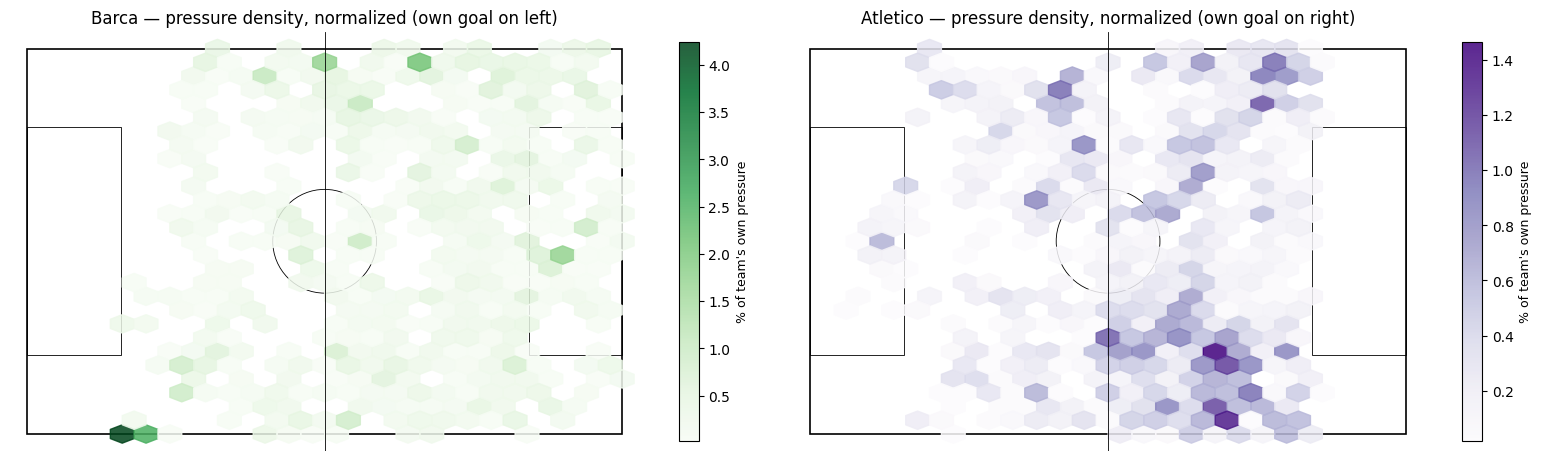

In [15]:
BOUNDS_TOLERANCE_M = 2.0

pressure_points = team_pressure_full[team_pressure_full["under_team_pressure"]].dropna(subset=["press_x", "press_y"]).copy()

pressure_points_clean = pressure_points[
    (pressure_points["press_x"] >= -BOUNDS_TOLERANCE_M) & (pressure_points["press_x"] <= PITCH_LENGTH + BOUNDS_TOLERANCE_M) &
    (pressure_points["press_y"] >= -BOUNDS_TOLERANCE_M) & (pressure_points["press_y"] <= PITCH_WIDTH + BOUNDS_TOLERANCE_M)
].copy()

n_dropped = len(pressure_points) - len(pressure_points_clean)
print(f"dropped {n_dropped} / {len(pressure_points)} pressure points outside pitch bounds (+/- {BOUNDS_TOLERANCE_M}m)")
print(pressure_points_clean.groupby("team").size())

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, team_id, label, cmap in zip(axes, [0, 1], ["Barca", "Atletico"], ["Greens", "Purples"]):
    sub = pressure_points_clean[pressure_points_clean["team"] == team_id]

    ax.add_patch(patches.Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH, fill=False, color="black", linewidth=1.2))
    ax.axvline(PITCH_LENGTH / 2, color="black", linewidth=0.6)
    ax.add_patch(patches.Circle((PITCH_LENGTH / 2, PITCH_WIDTH / 2), 9.15, fill=False, color="black", linewidth=0.6))
    box_depth, box_width = 16.5, 40.3
    ax.add_patch(patches.Rectangle((0, (PITCH_WIDTH - box_width) / 2), box_depth, box_width, fill=False, color="black", linewidth=0.6))
    ax.add_patch(patches.Rectangle((PITCH_LENGTH - box_depth, (PITCH_WIDTH - box_width) / 2), box_depth, box_width, fill=False, color="black", linewidth=0.6))

    weights = np.full(len(sub), 1.0 / len(sub) * 100)
    hb = ax.hexbin(sub["press_x"], sub["press_y"], C=weights, reduce_C_function=np.sum,
                    gridsize=25, cmap=cmap, mincnt=1, extent=(0, PITCH_LENGTH, 0, PITCH_WIDTH), alpha=0.85)
    cb = plt.colorbar(hb, ax=ax, shrink=0.7)
    cb.set_label("% of team's own pressure", fontsize=9)

    own_goal_side = "left" if team_id == 0 else "right"
    ax.set_title(f"{label} — pressure density, normalized (own goal on {own_goal_side})", fontsize=12)
    ax.set_xlim(-3, PITCH_LENGTH + 3)
    ax.set_ylim(-3, PITCH_WIDTH + 3)
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [35]:
## Diagnostic: what's driving the concentrated corner-zone pressure cluster for team 0
## Checks whether the dark hex near the corner is one sustained passage of play or genuinely
## distributed events -- needed before deciding whether to change the in_own_box exclusion.

CORNER_ZONE_X_MAX = 30  # just beyond the 16.5m box exclusion, catches the corner/wide-defending band

corner_zone_events = team_pressure_events[
    (team_pressure_events["team"] == 0)
].copy()

# re-attach zone info by checking the ball position at event midpoint
corner_zone_events["mid_frame"] = ((corner_zone_events["start_frame"] + corner_zone_events["end_frame"]) / 2).astype(int)
ball_x_lookup = ball_frame_table.set_index("frame_idx")["ball_pitch_x"]
corner_zone_events["mid_press_x"] = corner_zone_events["mid_frame"].map(ball_x_lookup)

corner_zone_events = corner_zone_events[
    (corner_zone_events["mid_press_x"] > BOX_DEPTH_M) & (corner_zone_events["mid_press_x"] <= CORNER_ZONE_X_MAX)
].sort_values("duration_sec", ascending=False)

print(f"team 0 pressure events with midpoint between {BOX_DEPTH_M}m and {CORNER_ZONE_X_MAX}m from own goal:")
print(f"{len(corner_zone_events)} events, {corner_zone_events['duration_sec'].sum():.1f}s total")
print()
print(corner_zone_events[["start_frame", "end_frame", "duration_sec", "mean_n_pressing"]].head(10))

team 0 pressure events with midpoint between 16.5m and 30m from own goal:
7 events, 13.7s total

     start_frame  end_frame  duration_sec  mean_n_pressing
68         56826      56989          5.60         0.128571
54         47220      47287          2.72         0.000000
55         47432      47492          2.44         0.000000
69         57574      57596          0.92         1.000000
40         35253      35272          0.80         1.300000
101        67514      67663          0.68         0.000000
103        68769      68782          0.56         0.000000


## 12. Possession events (keep-last gap fill) + pressure per event
Match is split into possession events by forward-filling every no-carrier (NONE) gap onto the last known `possession_team`, then run-length-encoding the result. For each event, the out-of-possession team's frame-level pressure signal (section 3) is averaged over that event's frames; the final per-team number is a duration-weighted mean across events, so a 40s press counts more than a 2s one.

In [16]:
poss_raw = ball_frame_table[["frame_idx", "possession_team"]].sort_values("frame_idx").reset_index(drop=True)
poss_raw = poss_raw.merge(stoppage_frame_lookup.rename("is_stoppage"), left_on="frame_idx", right_index=True, how="left")
poss_raw["is_stoppage"] = poss_raw["is_stoppage"].fillna(False)

poss_raw["possession_team_filled"] = poss_raw["possession_team"].ffill()
poss_raw = poss_raw.dropna(subset=["possession_team_filled"]).reset_index(drop=True)
poss_raw["possession_team_filled"] = poss_raw["possession_team_filled"].astype(int)

# force a hard break at every stoppage -- even if the same team has the ball before and after,
# dead time should never let two possession events merge into one
poss_raw["grouping_state"] = np.where(poss_raw["is_stoppage"], -1, poss_raw["possession_team_filled"])
poss_raw["event_id"] = (poss_raw["grouping_state"] != poss_raw["grouping_state"].shift()).cumsum()

# drop the stoppage rows themselves -- dead time shouldn't count toward any event's duration,
# but the split they forced above is preserved
poss_raw_live = poss_raw[~poss_raw["is_stoppage"]].reset_index(drop=True)

possession_events = (
    poss_raw_live.groupby("event_id", as_index=False)
    .agg(
        possession_team=("possession_team_filled", "first"),
        start_frame=("frame_idx", "first"),
        end_frame=("frame_idx", "last"),
        n_frames=("frame_idx", "count"),
    )
)
possession_events["duration_sec"] = possession_events["n_frames"] / FPS
possession_events["pressing_team"] = 1 - possession_events["possession_team"]

print(f"{len(possession_events)} possession events (keep-last gap fill, split at stoppages >= {STOPPAGE_GAP_SEC}s)")
print(possession_events["duration_sec"].describe())

207 possession events (keep-last gap fill, split at stoppages >= 10.0s)
count    207.000000
mean      11.410048
std       13.179058
min        0.360000
25%        2.320000
50%        5.960000
75%       15.960000
max       78.640000
Name: duration_sec, dtype: float64


In [17]:
frame_to_event = poss_raw_live[["frame_idx", "event_id", "possession_team_filled"]]

tpf_events = tpf.merge(frame_to_event, on="frame_idx", how="inner")
# keep only rows where tpf's pressing team actually matches this event's out-of-possession team --
# drops the rare frames where raw carrier_team briefly disagreed with the smoothed possession_team
tpf_events = tpf_events[tpf_events["team"] != tpf_events["possession_team_filled"]].copy()

event_pressure = (
    tpf_events.groupby("event_id", as_index=False)
    .agg(
        mean_n_pressing=("n_pressing", "mean"),
        mean_frac_tight_blocked=("frac_tight_blocked", "mean"),
        pct_frames_under_pressure=("under_team_pressure", "mean"),
        n_frames_matched=("frame_idx", "count"),
    )
)

possession_events = possession_events.merge(event_pressure, on="event_id", how="left")
matched = possession_events["pct_frames_under_pressure"].notna().sum()
print(f"pressure computed for {matched} / {len(possession_events)} events "
      f"(unmatched events are ones where raw carrier_team never agreed with the filled possession_team)")

scored = possession_events.dropna(subset=["pct_frames_under_pressure"])

final_pressure_by_team = (
    scored.groupby("pressing_team")
    .apply(lambda g: pd.Series({
        "duration_weighted_pct_under_pressure": np.average(g["pct_frames_under_pressure"], weights=g["duration_sec"]) * 100,
        "simple_mean_pct_under_pressure": g["pct_frames_under_pressure"].mean() * 100,
        "n_events": len(g),
        "total_duration_sec": g["duration_sec"].sum(),
    }))
)
print("\nfinal pressure by pressing team (duration-weighted mean is the headline number):")
print(final_pressure_by_team)

pressure computed for 207 / 207 events (unmatched events are ones where raw carrier_team never agreed with the filled possession_team)

final pressure by pressing team (duration-weighted mean is the headline number):
               duration_weighted_pct_under_pressure  \
pressing_team                                         
0                                         33.435838   
1                                         26.486739   

               simple_mean_pct_under_pressure  n_events  total_duration_sec  
pressing_team                                                                
0                                   32.870160     106.0              989.64  
1                                   26.458557     101.0             1372.24  


C:\Users\user\AppData\Local\Temp\ipykernel_11396\624361213.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


## 13. PPDA (Passes per Defensive Action)
Measures pressing intensity: how many passes a team allows its opponent to complete outside *that team's own defensive third* (i.e. excluding their own last-ditch defending near their own goal) before making a defensive action -- an interception or a tackle (the close-range team-change transitions captured above) -- in that same zone. Lower PPDA = more aggressive, higher-up pressing. Both the numerator and denominator are classified relative to the *defending* team (whichever team's PPDA is being computed), not the team that had the ball -- a defensive action near your own goal is just normal defending and shouldn't count as pressing, regardless of who had possession. Goalkeeper saves/claims are already excluded from `defensive_actions` at the source, so shot-stopping doesn't get counted as a pressing action.

In [18]:
def zone_for_team(x, team):
    if pd.isna(x):
        return None
    if team == 0:
        if x < 35: return "own_third"
        elif x < 70: return "middle_third"
        else: return "attacking_third"
    else:
        if x > 70: return "own_third"
        elif x > 35: return "middle_third"
        else: return "attacking_third"

ppda_by_team = {}
ppda_detail = {}

for team_id in [0, 1]:
    opponent = 1 - team_id

    # numerator: opponent's completed passes, classified in THIS team's own zone convention --
    # excluded only when they happen in this team's own defensive third (last-ditch territory)
    opp_completed = passes_from_scratch[
        (passes_from_scratch["outcome"] == "completed") &
        (passes_from_scratch["passer_team"] == opponent)
    ].copy()
    opp_completed["zone"] = opp_completed["release_x"].apply(lambda x: zone_for_team(x, team_id))
    passes_allowed = int((opp_completed["zone"] != "own_third").sum())

    # denominator: this team's own defensive actions, same zone convention
    own_actions = defensive_actions[defensive_actions["defending_team"] == team_id].copy()
    own_actions["zone"] = own_actions["x"].apply(lambda x: zone_for_team(x, team_id))
    actions_made = int((own_actions["zone"] != "own_third").sum())

    ppda_by_team[team_id] = passes_allowed / actions_made if actions_made > 0 else np.nan
    ppda_detail[team_id] = {"passes_allowed": passes_allowed, "actions_made": actions_made}

print("passes allowed / defensive actions made, by team (excluding each team's own defensive third):")
for team_id in [0, 1]:
    print(f"team {team_id}: {ppda_detail[team_id]}")

print("\nPPDA by team (lower = more aggressive pressing):")
for team_id, val in ppda_by_team.items():
    print(f"team {team_id}: {val:.2f}")

passes allowed / defensive actions made, by team (excluding each team's own defensive third):
team 0: {'passes_allowed': 119, 'actions_made': 49}
team 1: {'passes_allowed': 158, 'actions_made': 25}

PPDA by team (lower = more aggressive pressing):
team 0: 2.43
team 1: 6.32


## 14. Pressure effectiveness — co-press count, intensity over time, regain rate
Three cheap additions on top of the already-validated pressure signal (section 3) and raw carrier data (section 8): how many defenders press together per event, whether pressing intensity holds up across the match, and how often pressure actually wins the ball back. These are the numbers most worth handing to an LLM downstream -- volume alone ("pressed for 32% of the time") says little without effectiveness attached.

In [19]:
# --- co-press count per event: lone chaser vs coordinated press ---
copress_records = []
for team_id, grp in team_pressure_events.groupby("team"):
    team_frames = tpf[tpf["team"] == team_id].sort_values("frame_idx")
    fidx = team_frames["frame_idx"].values
    npress = team_frames["n_pressing"].values
    starts = np.searchsorted(fidx, grp["start_frame"].values, side="left")
    ends = np.searchsorted(fidx, grp["end_frame"].values, side="right")
    for (idx, row), s, e in zip(grp.iterrows(), starts, ends):
        seg = npress[s:e]
        copress_records.append({
            "event_index": idx,
            "max_n_pressing": seg.max() if len(seg) else np.nan,
            "mean_n_pressing_event": seg.mean() if len(seg) else np.nan,
        })

copress_df = pd.DataFrame(copress_records).set_index("event_index")
team_pressure_events = team_pressure_events.join(copress_df)

print("max simultaneous pressers per event, by team:")
print(team_pressure_events.groupby("team")["max_n_pressing"].describe())

print("\nshare of events that were a coordinated press (max_n_pressing >= 2), by team:")
print(team_pressure_events.groupby("team")["max_n_pressing"].apply(lambda s: (s >= 2).mean() * 100).round(1))

max simultaneous pressers per event, by team:
      count      mean       std  min  25%  50%  75%  max
team                                                    
0     105.0  1.285714  0.977775  0.0  1.0  1.0  2.0  4.0
1     144.0  1.125000  0.907429  0.0  0.0  1.0  2.0  4.0

share of events that were a coordinated press (max_n_pressing >= 2), by team:
team
0    40.0
1    33.3
Name: max_n_pressing, dtype: float64


In [20]:
# --- pressing intensity over match time (5-minute bins), chronologically sorted, stoppages excluded ---
BIN_MINUTES = 5

tpf_binned = tpf.merge(stoppage_frame_lookup.rename("is_stoppage"), left_on="frame_idx", right_index=True, how="left")
tpf_binned["is_stoppage"] = tpf_binned["is_stoppage"].fillna(False)
tpf_binned = tpf_binned[~tpf_binned["is_stoppage"]].copy()
tpf_binned["time_bin"] = (tpf_binned["frame_idx"] / FPS // (BIN_MINUTES * 60)).astype(int)

pressing_by_bin = (
    tpf_binned.groupby(["team", "time_bin"])["under_team_pressure"]
    .mean()
    .reset_index()
    .rename(columns={"under_team_pressure": "pct_under_pressure"})
)
pressing_by_bin["pct_under_pressure"] = (pressing_by_bin["pct_under_pressure"] * 100).round(1)
pressing_by_bin["bin_label"] = pressing_by_bin["time_bin"].apply(
    lambda b: f"{b * BIN_MINUTES}-{(b + 1) * BIN_MINUTES}min"
)

pressing_intensity_timeline = (
    pressing_by_bin
    .sort_values("time_bin")
    .pivot(index="bin_label", columns="team", values="pct_under_pressure")
)
ordered_labels = pressing_by_bin.sort_values("time_bin")["bin_label"].unique()
pressing_intensity_timeline = pressing_intensity_timeline.loc[ordered_labels]

print("pressing intensity (% of out-of-possession time under pressure) by 5-minute bin, stoppages excluded:")
print(pressing_intensity_timeline)

pressing intensity (% of out-of-possession time under pressure) by 5-minute bin, stoppages excluded:
team          0     1
bin_label            
0-5min     46.0  23.8
5-10min    38.0  23.1
10-15min   26.4  32.2
15-20min   55.6  24.4
20-25min   39.0  20.7
25-30min   21.1  33.7
30-35min   34.3  27.3
35-40min   35.8  31.9
40-45min   36.4  24.0
45-50min   11.5  57.8


In [21]:
# --- mask low-sample bins: a bin with too few frames lets one short sequence swing the average ---
MIN_BIN_FRAMES = 500

# rebuild fresh from pressing_by_bin every time -- avoids mutating a possibly-stale table
# if this cell is re-run more than once or out of order
pressing_intensity_timeline = (
    pressing_by_bin
    .sort_values("time_bin")
    .pivot(index="bin_label", columns="team", values="pct_under_pressure")
)
ordered_labels = pressing_by_bin.sort_values("time_bin")["bin_label"].unique()
pressing_intensity_timeline = pressing_intensity_timeline.loc[ordered_labels]

bin_frame_counts = tpf_binned.groupby(["team", "time_bin"]).size().reset_index(name="n_frames")
bin_frame_counts["bin_label"] = bin_frame_counts["time_bin"].apply(
    lambda b: f"{b * BIN_MINUTES}-{(b + 1) * BIN_MINUTES}min"
)

low_sample = bin_frame_counts[bin_frame_counts["n_frames"] < MIN_BIN_FRAMES]

for _, row in low_sample.iterrows():
    pressing_intensity_timeline.loc[row["bin_label"], row["team"]] = np.nan

print(f"masked {len(low_sample)} team/bin cell(s) below MIN_BIN_FRAMES={MIN_BIN_FRAMES} (unreliable sample size):")
print(low_sample[["bin_label", "team", "n_frames"]])

print("\npressing intensity timeline, low-sample bins masked as NaN:")
print(pressing_intensity_timeline)

masked 1 team/bin cell(s) below MIN_BIN_FRAMES=500 (unreliable sample size):
   bin_label  team  n_frames
19  45-50min     1       223

pressing intensity timeline, low-sample bins masked as NaN:
team          0     1
bin_label            
0-5min     46.0  23.8
5-10min    38.0  23.1
10-15min   26.4  32.2
15-20min   55.6  24.4
20-25min   39.0  20.7
25-30min   21.1  33.7
30-35min   34.3  27.3
35-40min   35.8  31.9
40-45min   36.4  24.0
45-50min   11.5   NaN


In [22]:
# --- pressure -> regain conversion rate ---
MAX_REGAIN_SEC = 5.0
MAX_REGAIN_FRAMES = int(MAX_REGAIN_SEC * FPS)

raw_carrier_lookup = (
    ball_frame_table.dropna(subset=["carrier_team"])[["frame_idx", "carrier_team"]]
    .sort_values("frame_idx")
)
_carrier_frame_idx = raw_carrier_lookup["frame_idx"].values
_carrier_team_vals = raw_carrier_lookup["carrier_team"].values

def regained_within_window(team_id, end_frame):
    lo = np.searchsorted(_carrier_frame_idx, end_frame, side="left")
    hi = np.searchsorted(_carrier_frame_idx, end_frame + MAX_REGAIN_FRAMES, side="right")
    window_teams = _carrier_team_vals[lo:hi]
    return bool(np.any(window_teams == team_id))

team_pressure_events["regained_ball"] = team_pressure_events.apply(
    lambda r: regained_within_window(r["team"], r["end_frame"]), axis=1
)

regain_summary = (
    team_pressure_events.groupby("team")["regained_ball"]
    .agg(["mean", "sum", "count"])
    .rename(columns={"mean": "regain_rate"})
)
regain_summary["regain_rate"] = (regain_summary["regain_rate"] * 100).round(1)
print(f"pressure -> regain conversion rate (ball won back by the pressing team within {MAX_REGAIN_SEC}s of the event ending):")
print(regain_summary)

pressure -> regain conversion rate (ball won back by the pressing team within 5.0s of the event ending):
      regain_rate  sum  count
team                         
0            40.0   42    105
1            25.7   37    144


## 15. Pressure outcome taxonomy
Pressure *volume* (`under_team_pressure`, PPDA, regain rate) says a press happened -- it doesn't say what it did to the buildup. This section classifies every resolved carrier transition into what actually happened to it: progressed forward anyway, forced backward, forced sideways, lost to an interception, lost to a tackle, or lost to a long ball / unresolved gap (previously dropped entirely by the `MAX_RECEPTION_GAP_FRAMES` filter in section 10). Same `under_pressure` definition as section 10 -- sustained pressure in the lookback window, not a single flickering frame.

This is the table meant for the LLM narrative layer: it turns "Barca pressed for 42% of Atletico's possession" into "Barca's press forced backward or sideways passes on X% of pressured touches, on top of the Y% won back outright" -- causal language a raw pressure-time percentage can't produce.

In [ ]:
FORWARD_PROGRESS_THRESH_M = 3.0   # net advance toward the attacking goal, in the team's own attack direction
BACKWARD_THRESH_M = -3.0          # net retreat away from the attacking goal

def receiver_position(row):
    try:
        pos = pos_lookup.loc[(row["reception_frame"], row["receiver_track_id"])]
        return pos["pitch_x"], pos["pitch_y"]
    except KeyError:
        return np.nan, np.nan

recv_xy = passes_from_scratch.apply(receiver_position, axis=1, result_type="expand")
passes_from_scratch["receiver_x"] = recv_xy[0]
passes_from_scratch["receiver_y"] = recv_xy[1]

def progression_m(row):
    # positive = net advance toward the attacking goal, negative = net retreat, direction-corrected per team
    if pd.isna(row["receiver_x"]):
        return np.nan
    if row["passer_team"] == 0:
        return row["receiver_x"] - row["release_x"]
    else:
        return row["release_x"] - row["receiver_x"]

passes_from_scratch["progression_m"] = passes_from_scratch.apply(progression_m, axis=1)

def classify_pass_outcome(row):
    if row["outcome"] == "intercepted":
        return "lost_intercepted"
    if pd.isna(row["progression_m"]):
        return "unresolved"  # receiver position missing from player_frame_table at reception frame
    if row["progression_m"] >= FORWARD_PROGRESS_THRESH_M:
        return "progressed_forward"
    elif row["progression_m"] <= BACKWARD_THRESH_M:
        return "forced_backward"
    else:
        return "forced_sideways"

passes_from_scratch["pass_outcome_detail"] = passes_from_scratch.apply(classify_pass_outcome, axis=1)

print("pass outcome breakdown, under pressure vs not, by team:")
print(passes_from_scratch.groupby(["passer_team", "under_pressure", "pass_outcome_detail"]).size().unstack(fill_value=0))

In [ ]:
# --- tackles (already detected in section 10 as short-distance, different-team transitions,
#     but excluded from passes_from_scratch entirely -- pull them in as their own outcome) ---
tackle_outcomes = defensive_actions[defensive_actions["action_type"] == "tackle"][
    ["attacking_team", "frame"]
].rename(columns={"attacking_team": "team"}).copy()
tackle_outcomes["under_pressure"] = tackle_outcomes.apply(
    lambda r: was_under_pressure(r["team"], r["frame"]), axis=1
)
tackle_outcomes["pass_outcome_detail"] = "lost_tackled"
tackle_outcomes = tackle_outcomes.drop(columns="frame")

# --- large-gap carrier transitions (gap_frames > MAX_RECEPTION_GAP_FRAMES), previously dropped
#     silently in section 10 -- capture as their own bucket: ball retained after the gap
#     (throw-in, stoppage, loose-ball scramble the same team won back) vs lost after it ---
long_gap_records = []
for i in range(len(carrier_runs_full) - 1):
    passer = carrier_runs_full.loc[i]
    receiver = carrier_runs_full.loc[i + 1]
    gap_frames = receiver["start_frame"] - passer["end_frame"]
    if gap_frames <= MAX_RECEPTION_GAP_FRAMES:
        continue  # already handled above as a resolved pass / interception / tackle

    same_team = receiver["team"] == passer["team"]
    long_gap_records.append({
        "team": int(passer["team"]),
        "under_pressure": was_under_pressure(passer["team"], passer["end_frame"]),
        "pass_outcome_detail": "retained_after_gap" if same_team else "lost_after_long_ball",
    })

long_gap_events = pd.DataFrame(long_gap_records)
print(f"{len(long_gap_events)} large-gap transitions captured (previously dropped entirely)")
if len(long_gap_events):
    print(long_gap_events.groupby(["team", "under_pressure", "pass_outcome_detail"]).size())

In [ ]:
# --- unified outcome table: every resolved carrier transition, one row each, ready for the LLM layer ---
FINAL_OUTCOME_ORDER = [
    "progressed_forward", "forced_sideways", "forced_backward",
    "lost_intercepted", "lost_tackled", "lost_after_long_ball",
    "retained_after_gap", "unresolved",
]

pass_outcomes = passes_from_scratch[["passer_team", "under_pressure", "pass_outcome_detail"]].rename(
    columns={"passer_team": "team"}
)

outcome_events = pd.concat([pass_outcomes, tackle_outcomes, long_gap_events], ignore_index=True)
outcome_events["pass_outcome_detail"] = pd.Categorical(
    outcome_events["pass_outcome_detail"], categories=FINAL_OUTCOME_ORDER, ordered=True
)

outcome_counts = (
    outcome_events.groupby(["team", "under_pressure", "pass_outcome_detail"], observed=False)
    .size()
    .unstack(fill_value=0)
)
print("carrier-transition outcomes by team and pressure state (counts):")
print(outcome_counts)

outcome_pct = outcome_counts.div(outcome_counts.sum(axis=1), axis=0) * 100
print("\nsame table as % within each team/pressure-state row:")
print(outcome_pct.round(1))

# headline: of the carrier actions a team made WHILE UNDER PRESSURE, what share were disrupted
# in some way (not clean forward progression) -- this is the opponent's press-effectiveness number,
# so index it by the team that got disrupted and remember the credit belongs to (1 - team)
DISRUPTIVE = ["forced_backward", "forced_sideways", "lost_intercepted", "lost_tackled", "lost_after_long_ball"]
pressured = outcome_events[outcome_events["under_pressure"] == True].copy()
pressured["disrupted"] = pressured["pass_outcome_detail"].isin(DISRUPTIVE)
disruption_rate = pressured.groupby("team")["disrupted"].mean() * 100

print("\n% of a team's own pressured carrier actions that were disrupted in some way")
print("(credit for the disruption belongs to the OPPOSING team's press):")
print(disruption_rate.round(1))

## 15b. Pressure outcome taxonomy by pitch zone
Same taxonomy as section 15, split by the zone each transition happened in -- reuses `zone_for_team` from section 13 (PPDA), so the zone convention matches everywhere else in the notebook. Tells you not just how effective a team's pressure was, but *where*: winning the ball back in the attacking third is worth far more than shepherding it sideways in your own defensive third, and the flat section-15 numbers can't distinguish the two.

In [ ]:
# --- rebuild the three outcome sources with a zone column attached ---

pass_outcomes_z = passes_from_scratch[["passer_team", "under_pressure", "pass_outcome_detail", "release_x"]].rename(
    columns={"passer_team": "team"}
).copy()
pass_outcomes_z["zone"] = pass_outcomes_z.apply(lambda r: zone_for_team(r["release_x"], r["team"]), axis=1)
pass_outcomes_z = pass_outcomes_z.drop(columns="release_x")

tackle_outcomes_z = defensive_actions[defensive_actions["action_type"] == "tackle"][
    ["attacking_team", "frame", "x"]
].rename(columns={"attacking_team": "team"}).copy()
tackle_outcomes_z["under_pressure"] = tackle_outcomes_z.apply(
    lambda r: was_under_pressure(r["team"], r["frame"]), axis=1
)
tackle_outcomes_z["pass_outcome_detail"] = "lost_tackled"
tackle_outcomes_z["zone"] = tackle_outcomes_z.apply(lambda r: zone_for_team(r["x"], r["team"]), axis=1)
tackle_outcomes_z = tackle_outcomes_z.drop(columns=["frame", "x"])

long_gap_records_z = []
for i in range(len(carrier_runs_full) - 1):
    passer = carrier_runs_full.loc[i]
    receiver = carrier_runs_full.loc[i + 1]
    gap_frames = receiver["start_frame"] - passer["end_frame"]
    if gap_frames <= MAX_RECEPTION_GAP_FRAMES:
        continue  # already covered by pass_outcomes_z / tackle_outcomes_z

    try:
        release_x = pos_lookup.loc[(passer["end_frame"], passer["track_id"])]["pitch_x"]
    except KeyError:
        release_x = np.nan

    same_team = receiver["team"] == passer["team"]
    long_gap_records_z.append({
        "team": int(passer["team"]),
        "under_pressure": was_under_pressure(passer["team"], passer["end_frame"]),
        "pass_outcome_detail": "retained_after_gap" if same_team else "lost_after_long_ball",
        "zone": zone_for_team(release_x, int(passer["team"])) if pd.notna(release_x) else None,
    })

long_gap_events_z = pd.DataFrame(long_gap_records_z)

outcome_events_z = pd.concat([pass_outcomes_z, tackle_outcomes_z, long_gap_events_z], ignore_index=True)
outcome_events_z["pass_outcome_detail"] = pd.Categorical(
    outcome_events_z["pass_outcome_detail"], categories=FINAL_OUTCOME_ORDER, ordered=True
)

n_missing_zone = outcome_events_z["zone"].isna().sum()
print(f"{n_missing_zone} events with unresolvable zone (missing position), dropped from the zone breakdown")
outcome_events_z = outcome_events_z.dropna(subset=["zone"])

In [ ]:
# --- disruption rate and turnover rate, by team and zone, pressured actions only ---
ZONE_ORDER = ["own_third", "middle_third", "attacking_third"]

pressured_z = outcome_events_z[outcome_events_z["under_pressure"] == True].copy()
pressured_z["disrupted"] = pressured_z["pass_outcome_detail"].isin(DISRUPTIVE)
pressured_z["turned_over"] = pressured_z["pass_outcome_detail"].isin(
    ["lost_intercepted", "lost_tackled", "lost_after_long_ball"]
)

zone_summary = (
    pressured_z.groupby(["team", "zone"])
    .agg(n_events=("disrupted", "size"), disruption_rate=("disrupted", "mean"), turnover_rate=("turned_over", "mean"))
)
zone_summary["disruption_rate"] = (zone_summary["disruption_rate"] * 100).round(1)
zone_summary["turnover_rate"] = (zone_summary["turnover_rate"] * 100).round(1)
zone_summary = zone_summary.reindex(pd.MultiIndex.from_product([[0, 1], ZONE_ORDER], names=["team", "zone"]))

print("of a team's own pressured actions in each zone -- disruption rate and turnover rate")
print("(zone is relative to the team whose action this is; credit for the disruption/turnover belongs to the opponent's press):")
print(zone_summary)

## 16. Pressing triggers -- what state the receiver was in right before pressure arrived
No body-orientation model in the pipeline, so "back to goal" isn't directly measurable. These are position/motion-based proxies for the classic situations that invite a press: receiving near the touchline (options cut off on one side), receiving deep in your own third, receiving a backward-directed pass (reuses `progression_m` from section 15 -- ball was moving toward the receiver's own goal), receiving with few open passing lanes (reuses `frame_lane_summary` from section 2 -- isolated), and a slow/static first touch. For every completed pass reception, checks whether the receiving team came under opponent pressure within `PRESS_ONSET_WINDOW_SEC`, then reports how often a press actually follows each trigger vs the baseline rate.

In [ ]:
PRESS_ONSET_WINDOW_SEC = 2.0
PRESS_ONSET_WINDOW_FRAMES = int(PRESS_ONSET_WINDOW_SEC * FPS)
TOUCHLINE_DIST_THRESH_M = 8.0
ISOLATED_LANES_THRESH = 2  # fewer than this many open passing lanes counts as isolated

reception_triggers = passes_from_scratch[passes_from_scratch["outcome"] == "completed"][
    ["receiver_track_id", "passer_team", "reception_frame", "receiver_x", "receiver_y", "progression_m"]
].rename(columns={"passer_team": "team"}).dropna(subset=["receiver_x", "receiver_y"]).copy()

reception_triggers["zone"] = reception_triggers.apply(lambda r: zone_for_team(r["receiver_x"], r["team"]), axis=1)
reception_triggers["dist_to_touchline_m"] = np.minimum(
    reception_triggers["receiver_y"], PITCH_WIDTH - reception_triggers["receiver_y"]
)

reception_triggers["trigger_touchline"] = reception_triggers["dist_to_touchline_m"] < TOUCHLINE_DIST_THRESH_M
reception_triggers["trigger_deep_own_third"] = reception_triggers["zone"] == "own_third"
reception_triggers["trigger_backward_pass"] = reception_triggers["progression_m"] < 0

# open passing lanes at the reception frame, reusing frame_lane_summary from section 2
lane_lookup = frame_lane_summary.set_index("frame_idx")["n_lanes_open"]
reception_triggers["n_lanes_open"] = reception_triggers["reception_frame"].map(lane_lookup)
reception_triggers["trigger_isolated"] = reception_triggers["n_lanes_open"] < ISOLATED_LANES_THRESH

print(f"{reception_triggers['n_lanes_open'].isna().sum()} receptions with no lane data at that frame (dropped from trigger_isolated only)")

In [ ]:
# --- first-touch speed: how quickly the receiver moved the ball in the moment right after control ---
FIRST_TOUCH_WINDOW_FRAMES = int(0.4 * FPS)  # ~0.4s right after the touch
STATIC_TOUCH_SPEED_MPS = 1.5

def first_touch_speed(row):
    try:
        p0 = pos_lookup.loc[(row["reception_frame"], row["receiver_track_id"])]
        p1 = pos_lookup.loc[(row["reception_frame"] + FIRST_TOUCH_WINDOW_FRAMES, row["receiver_track_id"])]
    except KeyError:
        return np.nan
    dist_m = float(np.hypot(p1["pitch_x"] - p0["pitch_x"], p1["pitch_y"] - p0["pitch_y"]))
    return dist_m / (FIRST_TOUCH_WINDOW_FRAMES / FPS)

reception_triggers["first_touch_speed_mps"] = reception_triggers.apply(first_touch_speed, axis=1)
reception_triggers["trigger_static_touch"] = reception_triggers["first_touch_speed_mps"] < STATIC_TOUCH_SPEED_MPS

print(f"{reception_triggers['first_touch_speed_mps'].isna().sum()} receptions with no first-touch speed "
      f"(receiver missing from player_frame_table {FIRST_TOUCH_WINDOW_FRAMES} frames later -- likely a pass near a stoppage)")

In [ ]:
# --- did opponent pressure actually follow this reception, within PRESS_ONSET_WINDOW_SEC? ---
def press_follows_reception(row):
    team = int(row["team"])
    opponent = 1 - team
    frame0 = int(row["reception_frame"])
    for f in range(frame0, frame0 + PRESS_ONSET_WINDOW_FRAMES + 1):
        if press_flags.get((f, opponent), False):
            return True
    return False

reception_triggers["press_followed"] = reception_triggers.apply(press_follows_reception, axis=1)

TRIGGER_COLS = ["trigger_touchline", "trigger_deep_own_third", "trigger_backward_pass",
                "trigger_isolated", "trigger_static_touch"]

baseline_rate = reception_triggers["press_followed"].mean() * 100
print(f"baseline: a press follows any reception {baseline_rate:.1f}% of the time (n={len(reception_triggers)})\n")

for col in TRIGGER_COLS:
    with_trigger = reception_triggers[reception_triggers[col] == True]
    without_trigger = reception_triggers[reception_triggers[col] == False]
    print(f"{col}: press followed {with_trigger['press_followed'].mean()*100:.1f}% of the time "
          f"(n={len(with_trigger)}) vs {without_trigger['press_followed'].mean()*100:.1f}% otherwise")

print("\ntrigger prevalence and press-follow rate by receiving team (%):")
print((reception_triggers.groupby("team")[TRIGGER_COLS + ["press_followed"]].mean() * 100).round(1))

## 17. Team pressing profile -- summary
One table per team pulling together volume (section 4/12), effectiveness by zone (15b), counter-press response speed (8b), and reception triggers (16) -- everything an LLM narrative layer needs about a team's pressing identity in one place, instead of six separate printouts.

In [ ]:
TEAM_NAMES = {0: "Barca", 1: "Atletico"}

profile_rows = []
for team_id, opponent_id in [(0, 1), (1, 0)]:
    row = {"team": TEAM_NAMES[team_id]}

    # volume + regain (section 12 / section 14) -- both indexed by the PRESSING team
    row["pct_opp_possession_pressured"] = (
        final_pressure_by_team.loc[team_id, "duration_weighted_pct_under_pressure"]
        if team_id in final_pressure_by_team.index else np.nan
    )
    row["ppda"] = ppda_by_team.get(team_id, np.nan)
    row["press_event_regain_rate_pct"] = (
        regain_summary.loc[team_id, "regain_rate"] if team_id in regain_summary.index else np.nan
    )

    # outcome/turnover effectiveness by zone (section 15b) -- indexed by the team BEING pressured,
    # so this team's press effectiveness reads from the opponent's row
    for zone in ["own_third", "middle_third", "attacking_third"]:
        key = (opponent_id, zone)
        row[f"turnover_rate_{zone}"] = zone_summary.loc[key, "turnover_rate"] if key in zone_summary.index else np.nan

    # counter-press: this team's own regain rate when THEY pressed fast after losing the ball (section 8b)
    fast_row = summary[(summary["losing_team"] == team_id) & (summary["press_response"] == "fast")]
    row["counter_press_fast_regain_rate_pct"] = (
        fast_row["regain_rate_pct"].values[0] if len(fast_row) and fast_row["turnovers"].values[0] > 0 else np.nan
    )

    # baseline: how often does this team's press actually follow an opponent's reception at all (section 16)
    opp_receptions = reception_triggers[reception_triggers["team"] == opponent_id]
    row["press_follow_rate_on_opp_receptions_pct"] = (
        opp_receptions["press_followed"].mean() * 100 if len(opp_receptions) else np.nan
    )

    profile_rows.append(row)

team_pressing_profile = pd.DataFrame(profile_rows).set_index("team").round(1)
print(team_pressing_profile.T)

In [ ]:
# --- one-paragraph auto-summary per team, the shape an LLM prompt actually wants ---
for team_id in [0, 1]:
    name = TEAM_NAMES[team_id]
    r = team_pressing_profile.loc[name]
    print(f"{name}:")
    print(
        f"  Pressed the opponent for {r['pct_opp_possession_pressured']:.1f}% of their out-of-possession time "
        f"(PPDA {r['ppda']:.2f}), regaining the ball within 5s of a press event {r['press_event_regain_rate_pct']:.1f}% of the time."
    )
    print(
        f"  Turnover rate when pressing: {r['turnover_rate_own_third']:.1f}% (own third) / "
        f"{r['turnover_rate_middle_third']:.1f}% (middle) / {r['turnover_rate_attacking_third']:.1f}% (attacking third)."
    )
    print(
        f"  When they pressed within 5s of losing the ball themselves, regained it {r['counter_press_fast_regain_rate_pct']:.1f}% of the time."
    )
    print()

## 18. Team shape compactness -- width and depth of the outfield block
Per-frame team depth (distance between the back line and the front line, along each team's own attack direction -- last-3 vs front-3 outfield players, same last-3 convention as the defensive-line baseline in section 0) and width (lateral spread across the pitch, IQR-trimmed so one stray tracked position doesn't blow up the number, same safeguard `remove_outliers_iqr` uses in section 6). Restricted to out-of-possession frames -- a team's real defensive shape, not inflated by attacking-phase positioning, same convention as everywhere else in this notebook. Reuses `outfield` (in-bounds, `dist_from_own_goal` already computed) and `poss` from section 6.

Also checks whether a team's shape actually tightens while actively pressing vs its resting out-of-possession shape. (Tried linking compactness to press-event regain outcomes too -- dropped: correlations with co-press count came back near zero and the regain-outcome split produced small, inconsistent, unexplainable cells across zones and teams. Not reliable enough to keep.)

In [ ]:
BACK_N = 3
FRONT_N = 3
WIDTH_IQR_MULT = 1.5
MIN_PLAYERS_FOR_SHAPE = BACK_N + FRONT_N  # need enough tracked outfield players for depth to mean anything

_shape_base = outfield.merge(poss, on="frame_idx", how="left")
_shape_base = _shape_base[
    _shape_base["possession_team"].notna() & (_shape_base["team"] != _shape_base["possession_team"])
]

def _team_frame_depth(df):
    d = df.sort_values("dist_from_own_goal")
    n = len(d)
    if n < MIN_PLAYERS_FOR_SHAPE:
        return pd.Series({"back_line_m": np.nan, "front_line_m": np.nan, "depth_m": np.nan, "n_players": n})
    back = d.head(BACK_N)["dist_from_own_goal"].mean()
    front = d.tail(FRONT_N)["dist_from_own_goal"].mean()
    return pd.Series({"back_line_m": back, "front_line_m": front, "depth_m": front - back, "n_players": n})

def _team_frame_width(y_vals):
    y = np.asarray(y_vals)
    if len(y) < 4:
        return np.nan
    q1, q3 = np.percentile(y, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - WIDTH_IQR_MULT * iqr, q3 + WIDTH_IQR_MULT * iqr
    y_trimmed = y[(y >= lo) & (y <= hi)]
    return float(y_trimmed.max() - y_trimmed.min()) if len(y_trimmed) else np.nan

depth_per_frame = _shape_base.groupby(["frame_idx", "team"]).apply(_team_frame_depth).reset_index()
depth_per_frame = depth_per_frame.dropna(subset=["depth_m"])

width_per_frame = (
    _shape_base.groupby(["frame_idx", "team"])["pitch_y"]
    .apply(_team_frame_width)
    .reset_index(name="width_m")
)

team_shape = depth_per_frame.merge(width_per_frame, on=["frame_idx", "team"], how="inner")
team_shape["compactness_area_m2"] = team_shape["depth_m"] * team_shape["width_m"]

print("out-of-possession team shape, by team (smaller area = more compact block):")
print(team_shape.groupby("team")[["depth_m", "width_m", "compactness_area_m2"]].agg(["mean", "median", "std"]))

In [ ]:
# --- does a team actually get tighter when it's actively pressing, or is shape constant regardless? ---
team_shape_pressure = team_shape.merge(
    tpf[["frame_idx", "team", "under_team_pressure"]], on=["frame_idx", "team"], how="left"
)

print("compactness area (m^2) while actively pressing vs not, by team:")
print(
    team_shape_pressure.groupby(["team", "under_team_pressure"])["compactness_area_m2"]
    .agg(["mean", "median", "count"])
)

## 19. Diagnostic summary
Run after executing the full notebook top to bottom. Prints the key checkpoints from every section so results can be sanity-checked in one place.

In [23]:
print("=" * 60)
print("0. STOPPAGES")
print("=" * 60)
print(f"{len(stoppages)} stoppages >= {STOPPAGE_GAP_SEC}s flagged, "
      f"{stoppages['duration_sec'].sum():.1f}s total dead time excluded from live-play calculations")

print("=" * 60)
print("1. POSSESSION EVENTS")
print("=" * 60)
print(f"{len(possession_events)} possession events (keep-last gap fill)")
print(possession_events["duration_sec"].describe())

print("\n" + "=" * 60)
print("2. PER-EVENT PRESSURE MATCH + FINAL AVERAGE")
print("=" * 60)
matched = possession_events["pct_frames_under_pressure"].notna().sum()
print(f"pressure computed for {matched} / {len(possession_events)} events "
      f"({matched / len(possession_events) * 100:.1f}%)")
print(final_pressure_by_team)

print("\n" + "=" * 60)
print("2b. PRESSING SIGNAL SANITY (gating, section 1)")
print("=" * 60)
print("share of off-ball rows within 5m that got GATED OUT (passive block, not real pressure):")
close_range = off_ball_pressure[off_ball_pressure["dist_to_carrier"] < PRESSURE_DIST_THRESH_M]
print(f"{(~close_range['is_pressuring']).mean() * 100:.1f}% of close-range rows excluded by the gate")
print("\nis_pressuring rate by team (close-range rows only):")
print(close_range.groupby("team")["is_pressuring"].mean())

print("\n" + "=" * 60)
print("3. PASS DETECTION")
print("=" * 60)
print(f"{len(passes_from_scratch)} pass attempts detected (from {len(carrier_runs_full)} carrier runs)")
print(passes_from_scratch["outcome"].value_counts())
print("\npass_distance_m stats:")
print(passes_from_scratch["pass_distance_m"].describe())
print(f"\n{len(defensive_actions)} defensive actions captured (GK saves excluded)")
print(defensive_actions["action_type"].value_counts())

print("\n" + "=" * 60)
print("4. PASSES UNDER PRESSURE")
print("=" * 60)
print("counts by team / pressure state:")
print(passes_from_scratch.groupby(["passer_team", "under_pressure"]).size())
print("\nsuccess rate table:")
print(pass_summary)

print("\n" + "=" * 60)
print("5. PPDA")
print("=" * 60)
print("passes allowed / defensive actions made, by team (excluding each team's own defensive third):")
for team_id in [0, 1]:
    print(f"team {team_id}: {ppda_detail[team_id]}")
print("\nPPDA by team (lower = more aggressive pressing):")
for team_id, val in ppda_by_team.items():
    print(f"team {team_id}: {val:.2f}")

print("\n" + "=" * 60)
print("6. PRESSURE EFFECTIVENESS (co-press, time bins, regain rate)")
print("=" * 60)
print("max simultaneous pressers per event, by team:")
print(team_pressure_events.groupby("team")["max_n_pressing"].describe())
print("\nshare of events that were a coordinated press (max_n_pressing >= 2), by team:")
print(team_pressure_events.groupby("team")["max_n_pressing"].apply(lambda s: (s >= 2).mean() * 100).round(1))
print("\npressing intensity (% of out-of-possession time under pressure) by 5-minute bin:")
print(pressing_intensity_timeline)
print(f"\npressure -> regain conversion rate (within {MAX_REGAIN_SEC}s of event end):")
print(regain_summary)

0. STOPPAGES
26 stoppages >= 10.0s flagged, 450.7s total dead time excluded from live-play calculations
1. POSSESSION EVENTS
207 possession events (keep-last gap fill)
count    207.000000
mean      11.410048
std       13.179058
min        0.360000
25%        2.320000
50%        5.960000
75%       15.960000
max       78.640000
Name: duration_sec, dtype: float64

2. PER-EVENT PRESSURE MATCH + FINAL AVERAGE
pressure computed for 207 / 207 events (100.0%)
               duration_weighted_pct_under_pressure  \
pressing_team                                         
0                                         33.435838   
1                                         26.486739   

               simple_mean_pct_under_pressure  n_events  total_duration_sec  
pressing_team                                                                
0                                   32.870160     106.0              989.64  
1                                   26.458557     101.0             1372.24  

2b. PRESSI

## 20. Position-based role feasibility check (exploratory -- nothing else in this notebook changed)
Before building anything on top of position-based roles instead of track identity, check whether a player's rank within the team's shape -- depth-order back-to-front -- actually stays stable over a tracklet's lifespan, or churns frame to frame. If it churns, "role" isn't a stable enough concept to substitute for identity either, and this whole direction isn't worth pursuing. Reuses `outfield` and `poss` from section 6, same out-of-possession restriction used throughout the notebook.

In [ ]:
_role_base = outfield.merge(poss, on="frame_idx", how="left")
_role_base = _role_base[
    _role_base["possession_team"].notna() & (_role_base["team"] != _role_base["possession_team"])
].copy()

# depth_rank: 0 = deepest defender (closest to own goal) ... n-1 = most advanced outfield player, per frame/team
_role_base["depth_rank"] = (
    _role_base.groupby(["frame_idx", "team"])["dist_from_own_goal"].rank(method="first").astype(int) - 1
)
_role_base["n_players_frame"] = _role_base.groupby(["frame_idx", "team"])["track_id"].transform("count")

print(f"{len(_role_base)} out-of-possession outfield rows with a depth_rank assigned")
print("players-per-frame distribution (should cluster near 10 -- full outfield XI minus GK):")
print(_role_base["n_players_frame"].describe())

In [ ]:
MIN_FRAMES_FOR_STABILITY_CHECK = 50  # ~2s @ 25fps -- ignore very short fragments, not representative

track_role_stats = []
for track_id, grp in _role_base.groupby("track_id"):
    if len(grp) < MIN_FRAMES_FOR_STABILITY_CHECK:
        continue
    mode_rank = grp["depth_rank"].mode().iloc[0]
    track_role_stats.append({
        "track_id": track_id,
        "team": grp["team"].iloc[0],
        "n_frames": len(grp),
        "mode_depth_rank": mode_rank,
        "depth_rank_stability": (grp["depth_rank"] == mode_rank).mean(),
        "depth_rank_std": grp["depth_rank"].std(),
    })

track_role_df = pd.DataFrame(track_role_stats)
print(f"{len(track_role_df)} tracklets with >= {MIN_FRAMES_FOR_STABILITY_CHECK} out-of-possession frames")

print("\ndepth_rank stability (share of a tracklet's own frames matching its most common rank):")
print(track_role_df["depth_rank_stability"].describe())

print("\ndepth_rank std within a tracklet (lower = tighter, more stable role):")
print(track_role_df["depth_rank_std"].describe())

In [ ]:
GOOD_STABILITY_THRESH = 0.6  # arbitrary but reasonable bar: holds its slot >= 60% of its own frames

pct_good = (track_role_df["depth_rank_stability"] >= GOOD_STABILITY_THRESH).mean() * 100
print(f"{pct_good:.1f}% of tracklets hold their most common depth-rank slot in "
      f">= {GOOD_STABILITY_THRESH*100:.0f}% of their own frames\n")

print("if this is high, position-based role is a viable proxy as-is.")
print("if this is low, depth_rank alone churns too much on its own -- would need smoothing")
print("(a rolling-window mode) or a coarser grouping (back-4 / mid / fwd tiers instead of")
print("exact rank) before it's usable, and that's the next thing to check rather than building")
print("straight on top of raw per-frame rank.")

In [ ]:
# --- exact rank churned too much (2.9% pass) -- test the coarser fallback: back/mid/fwd thirds
#     instead of exact position, using proportional rank so it's robust to n_players_frame varying 9-12 ---
_role_base["rank_frac"] = _role_base["depth_rank"] / (_role_base["n_players_frame"] - 1).clip(lower=1)
_role_base["depth_tier"] = pd.cut(
    _role_base["rank_frac"], bins=[-0.01, 0.34, 0.67, 1.01], labels=["back", "mid", "fwd"]
)

tier_stats = []
for track_id, grp in _role_base.groupby("track_id"):
    if len(grp) < MIN_FRAMES_FOR_STABILITY_CHECK:
        continue
    mode_tier = grp["depth_tier"].mode().iloc[0]
    tier_stats.append({
        "track_id": track_id,
        "team": grp["team"].iloc[0],
        "n_frames": len(grp),
        "mode_depth_tier": mode_tier,
        "depth_tier_stability": (grp["depth_tier"] == mode_tier).mean(),
    })

tier_df = pd.DataFrame(tier_stats)
print("depth_tier (back/mid/fwd thirds) stability -- share of a tracklet's own frames matching its most common tier:")
print(tier_df["depth_tier_stability"].describe())

pct_good_tier = (tier_df["depth_tier_stability"] >= GOOD_STABILITY_THRESH).mean() * 100
print(f"\n{pct_good_tier:.1f}% of tracklets hold their most common tier in >= {GOOD_STABILITY_THRESH*100:.0f}% of their own frames")
print("(compare to 2.9% for exact rank -- if this is much higher, back/mid/fwd tiers are viable")
print("even though exact numeric position isn't)")